# Choices13k: Predicting Choice Behavior in Risky Gambles

## Introduction

This notebook analyzes the [**Choices13k**](https://github.com/jcpeterson/choices13k) dataset, which contains human choices between pairs of lotteries (gambles) with feedback. The goal is to predict the **choice rate** (`bRate`: proportion of times option B was chosen) from problem and gamble features, using the problem definitions in `c13k_problems.json` and the selection data in `c13k_selections.csv`.

The analysis proceeds as follows:

1. **Data fetching and loading** — Download or load the selections CSV and problems JSON from the Choices13k repository, then merge them into a single dataframe.
2. **Data quality** — Check for duplicate problems and inspect feedback patterns.
3. **Exploratory data analysis** — Summarize the merged data, inspect the target (`bRate`), and examine correlations with the target.
4. **Feature engineering** — Derive numeric features from the gamble structure (e.g. expected value, standard deviation, extreme outcomes, BEAST-style features).
5. **Modeling** — Train and compare multiple regressors (Ridge, Random Forest, SVR, Gradient Boosting, XGBoost, LightGBM, etc.) with hyperparameter search and evaluate on held-out test data.

We first have to download the required packages

In [169]:
# Run this cell once to install dependencies (works on both Colab and local Jupyter).
# Uncomment the line below, run the cell, then you can comment it again to avoid reinstalling every time.
%pip install numpy pandas matplotlib seaborn scikit-learn scipy requests optuna torch xgboost lightgbm shap

In [170]:
# --- Standard library ---
import ast
import json
import os
from urllib.parse import urlparse
from dataclasses import dataclass
from typing import Any, Dict, Optional

# --- Third-party ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from scipy.stats import probplot
from IPython.display import display
import shap  # optional, for run_experiment diagnostics

# --- sklearn ---
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## 1. Fetching the data

We download the selections and problem files from the Choices13k repository if they are not already present locally.


In [171]:
def download_file(url, save_path=None):
    try:
        response = requests.get(url, stream=True, timeout=15)
        response.raise_for_status()

        if save_path is None:
            filename = os.path.basename(urlparse(url).path) or "downloaded_file"
            save_path = os.path.join(os.getcwd(), filename)

        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024

        downloaded_size = 0
        with open(save_path, 'wb') as file:
            for data in response.iter_content(block_size):
                file.write(data)


        print(f"\nDownload complete: {save_path}")

    except requests.exceptions.MissingSchema:
        print("Invalid URL format.")
    except requests.exceptions.ConnectionError:
        print("Connection error. Check your internet connection.")
    except requests.exceptions.Timeout:
        print("Request timed out.")
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


We download the 2 files. `c13k_problems.json` contains the problem descriptions and `c13k_selections.csv` contains additional info about the gambles and the target variable,`brate`.

In [172]:
BASE_URL = 'https://raw.githubusercontent.com/jcpeterson/choices13k/refs/heads/main'

csv_url = f'{BASE_URL}/c13k_selections.csv'
json_url = f'{BASE_URL}/c13k_problems.json'

if not os.path.exists('c13k_selections.csv'):
    download_file(csv_url)
if not os.path.exists('c13k_problems.json'):
    download_file(json_url)

We then validate that the json is correct.

In [173]:
def validate_json_file(path: str) -> bool:
    try:
        with open(path, "r", encoding="utf-8") as f:
            json.load(f)
        print("JSON is valid")
        return True
    except json.JSONDecodeError as e:
        print("Invalid JSON:", e)
        return False

validate_json_file("c13k_problems.json")


JSON is valid


True

### 1.1 Loading and merging the data

We load the selections CSV and the problems JSON, then join them on the problem identifier to obtain a single dataframe with both choice outcomes and gamble structure.

In [174]:
df = pd.read_csv('c13k_selections.csv')
df.head()
df.isnull().sum()

,0
Problem,0
Feedback,0
n,0
Block,0
Ha,0
pHa,0
La,0
Hb,0
pHb,0
Lb,0


In [175]:
len(df)

14568

In [176]:
problems = pd.read_json("c13k_problems.json", orient='index')
problems

,B,A
0,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...
14563,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


In [177]:
selections = pd.read_csv('c13k_selections.csv')

with pd.option_context('display.max_columns', None):
    display(selections)

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476


In [178]:
selections.columns = [col.lower() for col in selections.columns]

In [179]:
df_full = selections.join(problems, how='left')

In [180]:
with pd.option_context('display.max_columns', None):
    display(df_full)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


### Column descriptions

| Column | Type | Description |
|--------|------|-------------|
| **problem** | Integer | A unique internal problem ID. |
| **n** | Integer | The number of subjects run on the current problem. |
| **feedback** | Boolean | Whether the participants were given feedback about the reward they received and missed out on after making their selection. |
| **brate** | Float | **Target.** The frequency with which subjects selected Gamble B on the current problem. |
| **ha** | Integer | The first outcome of gamble A. |
| **pha** | Float | The probability of Ha in gamble A. |
| **la** | Integer | The second outcome of gamble A (occurs with probability 1−pHa). |
| **hb** | Integer | The expected value of the lottery in gamble B. |
| **phb** | Float | The probability of the lottery in gamble B. |
| **lb** | Float | The non-lottery outcome in gamble B (occurs with probability 1−pHb). |
| **lotshapeb** | {0, 1, 2, 3} | Shape of the lottery distribution for gamble B: 1 = symmetric around its mean, 2 = right-skewed, 3 = left-skewed, 0 = undefined (e.g. if LotNumB = 1). |
| **lotnumb** | Integer | The number of possible outcomes in the gamble B lottery. |
| **amb** | Boolean | Whether the decision maker could see the probabilities of the outcomes in Gamble B. 1 = no information (ambiguity), 0 = complete information. |
| **corr** | {-1, 0, 1} | Whether there is a correlation (negative, zero, or positive) between the payoffs of the two gambles. |
| **block** | {1, 2, 3, 4, 5} | The block ID for the current problem. For no feedback, Block is always 1; otherwise sampled uniformly from {2, 3, 4, 5}. |
| **brate_std** | Float | Empirical standard deviation of the choice proportion (not in official schema). |
| **A** | list | Full gamble A: list of `[outcome, probability]` pairs (from problems JSON). |
| **B** | list | Full gamble B: list of `[outcome, probability]` pairs (from problems JSON). |

We now have a unified dataset containing both the gambles descriptions and the choices.

## 2. Data quality and duplicates

We check for duplicate problem IDs and inspect the distribution of feedback (e.g. choice consistency across blocks).

In [181]:
counts = df_full.groupby('problem').size().reset_index(name='count').sort_values(by="count", ascending=False)

In [182]:
idx = counts.loc[counts["count"] > 1, "problem"].tolist()


In [183]:
df_full.loc[df_full['problem'].isin(idx),:]

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.866667,0.351866,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.962500,0.150000,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
8,8,False,15,1,27,1.00,27,89,0.50,-24,0,1,False,0,0.453333,0.403320,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
9,8,True,16,2,27,1.00,27,89,0.50,-24,0,1,False,0,0.612500,0.434933,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
11,10,False,15,1,1,1.00,1,59,0.05,0,0,1,True,0,0.773333,0.406143,"[[0.9500000000000001, 0.0], [0.05, 59.0]]","[[1.0, 1.0], [0.0, 1.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8293,6734,True,18,5,77,0.01,30,116,0.40,-12,2,5,True,0,0.688889,0.292834,"[[0.6000000000000001, -12.0], [0.2, 112.0], [0...","[[0.01, 77.0], [0.99, 30.0]]"
8296,6737,False,16,1,26,1.00,26,41,0.60,7,0,1,False,0,0.450000,0.287518,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8297,6737,True,16,3,26,1.00,26,41,0.60,7,0,1,False,0,0.600000,0.309839,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8299,6739,False,16,1,-1,0.95,-4,10,0.75,-17,2,3,False,0,0.787500,0.247319,"[[0.25, -17.0], [0.375, 8.0], [0.1875, 10.0], ...","[[0.9500000000000001, -1.0], [0.05, -4.0]]"


We can see that while the dataset reports 13,006 risky choice problems, our dataset has 3,124 additional rows.

In [184]:
df_full['feedback'].value_counts()

,count
feedback,
True,12188
False,2380


In [185]:
count = (
    df_full
    .groupby("problem")["feedback"]
    .nunique()
    .eq(2)
    .sum()
)

print(count)


1562


The reason behind the duplicate problem ids, is that in some cases some subjects were given feedback before their decision and therefore, one column is for subjects with feedback and one for subjects without feedback.

## 3. Exploratory data analysis

We first need to investigate the dataset, inspect the target variable `bRate`, and the correlations of the features with `bRate`.

### 3.1 Basic exploration

We inspect the merged dataset: the first few rows, summary statistics for all columns, and the count of missing values per column. We then plot the distribution of the target variable `bRate` (choice rate for option B) and a heatmap of the correlation matrix for all numeric features. This helps spot skewness, outliers, and pairwise correlations before modeling.

First 5 rows of df:


,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
problem,14568.0,NaN,NaN,NaN,6163.333677,3733.123605,1.0,2961.75,5888.5,9364.25,13006.0
feedback,14568,2,True,12188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n,14568.0,NaN,NaN,NaN,16.670717,2.588231,15.0,16.0,16.0,17.0,33.0
block,14568.0,NaN,NaN,NaN,3.099053,1.379569,1.0,2.0,3.0,4.0,5.0
ha,14568.0,NaN,NaN,NaN,22.014072,24.076396,-10.0,5.0,18.0,29.0,118.0
pha,14568.0,NaN,NaN,NaN,0.747192,0.351998,0.01,0.5,1.0,1.0,1.0
la,14568.0,NaN,NaN,NaN,3.813152,16.406765,-50.0,-6.0,5.0,17.0,30.0
hb,14568.0,NaN,NaN,NaN,35.583677,27.659754,-18.0,15.0,30.0,52.0,119.0
phb,14568.0,NaN,NaN,NaN,0.444946,0.325977,0.01,0.2,0.4,0.75,1.0
lb,14568.0,NaN,NaN,NaN,-4.147721,18.270573,-50.0,-16.0,-3.0,9.0,41.0



Missing values per column:
problem      0
feedback     0
n            0
block        0
ha           0
pha          0
la           0
hb           0
phb          0
lb           0
lotshapeb    0
lotnumb      0
amb          0
corr         0
brate        0
brate_std    0
B            0
A            0
dtype: int64


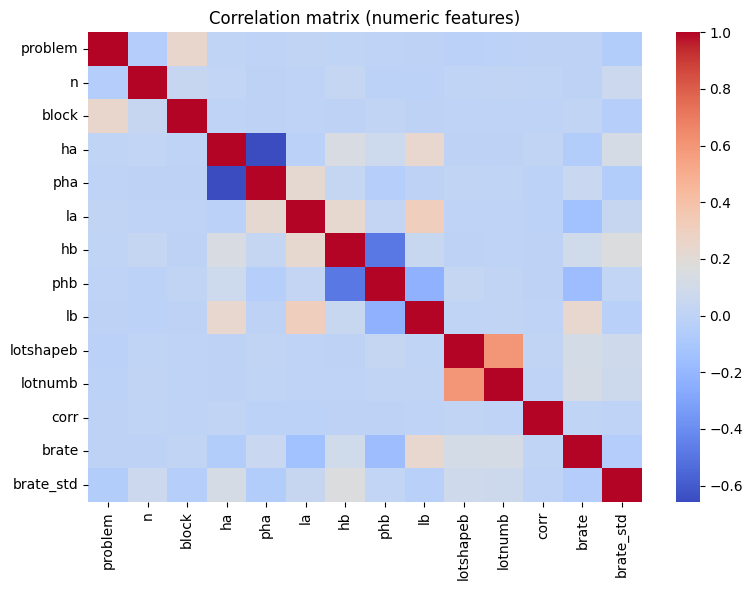

In [186]:
# Basic exploration of the dataset

print("First 5 rows of df:")
display(df_full.head())

# Summary statistics (numeric and categorical)
print("\nSummary statistics:")
display(df_full.describe(include="all").T)

# Missing values per column
print("\nMissing values per column:")
print(df_full.isnull().sum())

# Distribution of the main rate column
if "bRate" in df_full.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_full["bRate"], kde=True)
    plt.title("Distribution of bRate")
    plt.xlabel("bRate")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Correlation matrix for numeric features
numeric_df = df_full.select_dtypes(include=["number"])
if not numeric_df.empty:
    plt.figure(figsize=(8, 6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
    plt.show()

### Dataset Overview

- The dataset contains **14,568 observations** with a mix of numerical, binary, and structured features.
- The target variable **`brate`** is continuous in \([0, 1]\), with a mean of ≈ **0.52** and moderate dispersion.
- **No missing values** are present in any feature, eliminating the need for imputation.
- Several variables (e.g., `ha`, `hb`, `la`, `lb`) exhibit **wide ranges**, indicating heterogeneous choice contexts.

---

### Feature Characteristics

- Binary features such as `feedback` and `amb` are well-balanced enough to be informative.
- Count-based features (`n`, `block`, `lotnumb`) show limited variance, suggesting bounded experimental structure.
- Probability-like variables (`pha`, `phb`) are naturally constrained to \([0, 1]\).
- Structured variables (`A`, `B`) encode alternative-specific attributes and are later summarized through derived features.

---

### Correlation Structure (Numeric Features)

- Pairwise correlations are generally **low to moderate**, indicating limited multicollinearity.
- Stronger dependencies appear between:
  - `lotshapeb` and `lotnumb`, reflecting related design aspects of the choice task.
  - Alternative-specific quantities (`ha`, `hb`, `la`, `lb`) that encode symmetric information for options A and B.
- The target `brate` shows **weak marginal correlations** with individual predictors, consistent with earlier univariate analysis.

---

### Implications for Modeling

- The absence of dominant linear correlations suggests that `brate` depends on **joint feature interactions** rather than single predictors.
- Low multicollinearity supports the use of **regularized linear models (Ridge)** without instability.
- The structure of the data motivates exploring **non-linear models** to capture interactions and asymmetries between alternatives.


### 3.2 Correlation with the target

We compute each numeric feature's Pearson correlation with `bRate`, sort them by strength, and display both a table and a bar chart. Features with larger absolute correlation are stronger linear predictors of the choice rate and are good candidates for the model; weak correlations do not rule out nonlinear relationships that tree-based or kernel models can still capture.

Correlation of each numeric feature with brate (sorted):


,corr_with_bRate
lb,0.238497
lotnumb,0.122896
lotshapeb,0.112797
hb,0.092437
amb,0.087488
pha,0.053659
block,0.015038
corr,0.005025
feedback,0.003050
problem,-0.005596


/tmp/ipython-input-2802929659.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_brate.values, y=corr_with_brate.index, palette="viridis")


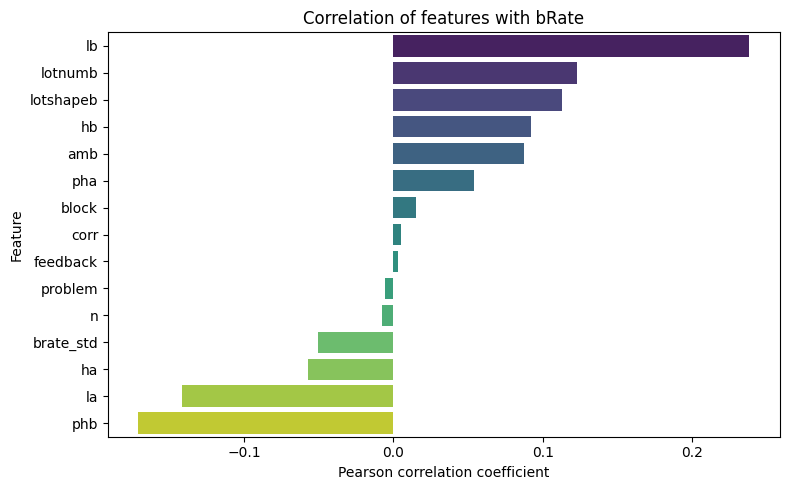

In [187]:
# Correlation of all numeric features with bRate

corr_matrix = df_full.corr(numeric_only=True)
corr_with_brate = corr_matrix["brate"].drop(labels=["brate"], errors="ignore").sort_values(ascending=False)

print("Correlation of each numeric feature with brate (sorted):")
display(corr_with_brate.to_frame(name="corr_with_bRate"))

# Bar plot of correlations
plt.figure(figsize=(8, 5))
sns.barplot(x=corr_with_brate.values, y=corr_with_brate.index, palette="viridis")
plt.title("Correlation of features with bRate")
plt.xlabel("Pearson correlation coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Correlation Analysis with `brate`

- Most individual features exhibit **weak-to-moderate linear correlation** with `brate`, indicating that no single variable dominates the prediction.
- **Positive correlations**:
  - `lb` shows the strongest positive association with `brate`, followed by `lotnumb` and `lotshapeb`.
  - `hb`, `amb`, and `pha` also contribute positively but with smaller effect sizes.
- **Negative correlations**:
  - `phb`, `la`, and `ha` are moderately negatively correlated with `brate`, suggesting inverse relationships.
  - `brate_std` shows a mild negative correlation, indicating higher variability may be associated with lower average `brate`.
- Several features (`block`, `corr`, `feedback`, `problem`, `n`) are **near-zero correlated**, implying limited standalone linear explanatory power.

**Interpretation**
- Low marginal correlations do **not** imply irrelevance: Ridge regression can still leverage these features through **joint effects and regularization**.
- The results suggest that `brate` is influenced by **combinations of features rather than single strong predictors**, motivating multivariate and potentially non-linear models.


## 4. Feature engineering

We derive numeric features from the raw gamble columns `A` and `B` (lists of outcome–probability pairs) so that standard ML models can use them. All new features are computed from the full gamble distributions.

**Overview of steps:**

1. **Numeric cleaning** — Round existing numeric columns to 2 decimals for consistency.
2. **Expected value and risk** — Compute EV and standard deviation per gamble; add differences (A − B).
3. **Extreme outcomes and minimum payoffs** — Flags for large gains/losses, EV difference, and worst-outcome comparison.
4. **Probability of positive payoff** — P(reward > 0) for each option and their difference.
5. **BEAST-style psychological features** — Probability A beats B, expected regret, probability of regret, and worst-outcome probabilities (inspired by models of risky choice).

### 4.1 Numeric cleaning

Round all numeric columns (except `problem`) to 2 decimal places so downstream computations and models see consistent precision.

In [188]:
numeric_cols = df_full.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    # Keep 'problem' as an identifier, don't round it
    if col != "problem":
        df_full[col] = df_full[col].round(2)

### 4.2 Expected value and risk

- **Helpers:** Parse gamble lists (support string or list), round (p, r) pairs, and compute **expected value** and **standard deviation** per gamble.
- **New columns:** `A_ev`, `B_ev`, `A_std`, `B_std`, then `std_diff` = A_std − B_std and `variance_diff` = A_std² − B_std².
- Raw `A` and `B` are rounded in place for consistency.

In [189]:
def _ensure_gamble_list(gamble_list):
    """Ensure we always work with a list[(p, r)]"""
    if isinstance(gamble_list, str):
        return ast.literal_eval(gamble_list)
    return gamble_list

def round_gamble_column(gamble_list, decimals=2):
    """Round probabilities and rewards to a fixed number of decimals."""
    gl = _ensure_gamble_list(gamble_list)
    return [(round(p, decimals), round(r, decimals)) for p, r in gl]

def calculate_gamble_stats(gamble_list):
    """
    Compute expected value (EV) and standard deviation for a gamble.

    gamble_list: list of (probability, reward) tuples
    returns: (ev, std_dev)
    """
    gl = _ensure_gamble_list(gamble_list)
    probs = [x[0] for x in gl]
    rewards = [x[1] for x in gl]

    ev = sum(p * r for p, r in zip(probs, rewards))
    variance = sum(p * (r - ev) ** 2 for p, r in zip(probs, rewards))
    std_dev = np.sqrt(variance)

    return round(ev, 2), round(std_dev, 2)

# Apply rounding to raw gamble columns
df_full["A"] = df_full["A"].apply(round_gamble_column)
df_full["B"] = df_full["B"].apply(round_gamble_column)

# Compute EV and std for each option
df_full["A_ev"], df_full["A_std"] = zip(*df_full["A"].apply(calculate_gamble_stats))
df_full["B_ev"], df_full["B_std"] = zip(*df_full["B"].apply(calculate_gamble_stats))

# Basic risk features
df_full["std_diff"] = df_full["A_std"] - df_full["B_std"]
df_full["variance_diff"] = df_full["A_std"] ** 2 - df_full["B_std"] ** 2

### 4.3 Extreme outcomes and minimum payoffs

- **Extreme outcomes:** Boolean flags for each gamble: `*_has_large_loss` (any outcome ≤ −20) and `*_has_large_gain` (any outcome ≥ 50).
- **EV difference:** `ev_diff` = A_ev − B_ev.
- **Worst outcome:** Minimum payoff per gamble (`A_min`, `B_min`) and `min_diff` = A_min − B_min.

In [190]:

def has_extreme_outcomes(gamble_list, loss_threshold=-20, gain_threshold=50):
    """
    Check if a gamble has extreme outcomes (large losses or gains).

    returns: (has_large_loss, has_large_gain)
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    has_large_loss = any(r <= loss_threshold for r in rewards)
    has_large_gain = any(r >= gain_threshold for r in rewards)
    return has_large_loss, has_large_gain

# Extreme outcome indicators for A and B
df_full["A_has_large_loss"], df_full["A_has_large_gain"] = zip(
    *df_full["A"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)
df_full["B_has_large_loss"], df_full["B_has_large_gain"] = zip(
    *df_full["B"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)

# EV difference
df_full["ev_diff"] = df_full["A_ev"] - df_full["B_ev"]

def get_min_outcome(gamble_list):
    """Get the minimum (worst) outcome from a gamble."""
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    return min(rewards)

# Worst outcomes and their difference
df_full["A_min"] = df_full["A"].apply(get_min_outcome)
df_full["B_min"] = df_full["B"].apply(get_min_outcome)
df_full["min_diff"] = df_full["A_min"] - df_full["B_min"]

### 4.4 Probability of positive payoff

Probability that a single draw from the gamble yields a **strictly positive** reward: P(reward > 0). We add `A_prob_positive`, `B_prob_positive`, and `prob_positive_diff` = A − B.

In [191]:

def prob_positive(gamble_list):
    """Calculate probability of getting a strictly positive payoff."""
    gl = _ensure_gamble_list(gamble_list)
    return sum(p for p, r in gl if r > 0)

df_full["A_prob_positive"] = df_full["A"].apply(prob_positive)
df_full["B_prob_positive"] = df_full["B"].apply(prob_positive)
df_full["prob_positive_diff"] = (
    df_full["A_prob_positive"] - df_full["B_prob_positive"]
)

### 4.5 Psychological features

| Feature | Description |
|--------|-------------|
| `prob_A_beats_B` | P(X_A > X_B) in one independent draw from each gamble (convolution of the two distributions). |
| `expected_regret` | Expected regret when choosing A: E[max(0, X_B − X_A)]. |
| `prob_regret` | P(X_B > X_A). |
| `A_prob_worst`, `B_prob_worst` | Probability of the worst (minimum) outcome in each gamble. |
| `prob_worst_diff` | A_prob_worst − B_prob_worst. |

A short sanity check displays the first rows of the engineered dataframe.

In [192]:

def prob_A_beats_B(gamble_A, gamble_B):
    """
    P(X_A > X_B) in a single draw by convolving the two distributions.
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_A_beats = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_A > r_B:
                prob_A_beats += p_A * p_B
    return prob_A_beats

df_full["prob_A_beats_B"] = df_full.apply(
    lambda row: prob_A_beats_B(row["A"], row["B"]), axis=1
)

def expected_regret(gamble_A, gamble_B):
    """
    Expected regret if choosing A: E[max(0, X_B - X_A)].
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    expected_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            regret = max(0, r_B - r_A)
            expected_regret_val += p_A * p_B * regret
    return expected_regret_val

df_full["expected_regret"] = df_full.apply(
    lambda row: expected_regret(row["A"], row["B"]), axis=1
)

def prob_regret(gamble_A, gamble_B):
    """
    Probability of regret: P(X_B > X_A).
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_B > r_A:
                prob_regret_val += p_A * p_B
    return prob_regret_val

df_full["prob_regret"] = df_full.apply(
    lambda row: prob_regret(row["A"], row["B"]), axis=1
)

def prob_worst_outcome(gamble_list):
    """
    Probability of hitting the worst (minimum) outcome.
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    min_reward = min(rewards)
    return sum(p for p, r in gl if r == min_reward)

df_full["A_prob_worst"] = df_full["A"].apply(prob_worst_outcome)
df_full["B_prob_worst"] = df_full["B"].apply(prob_worst_outcome)
df_full["prob_worst_diff"] = df_full["A_prob_worst"] - df_full["B_prob_worst"]

df_full.head(10)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,...,min_diff,A_prob_positive,B_prob_positive,prob_positive_diff,prob_A_beats_B,expected_regret,prob_regret,A_prob_worst,B_prob_worst,prob_worst_diff
0,1,True,15,2,26,0.95,-1,23,0.05,21,...,-22.0,0.95,1.00,-0.05,0.95,1.105,0.05,0.05,0.95,-0.90
1,2,True,15,4,14,0.60,-18,8,0.25,-5,...,-13.0,0.60,0.25,0.35,0.60,6.500,0.40,0.40,0.75,-0.35
2,3,True,17,4,2,0.50,0,1,1.00,1,...,-1.0,0.50,1.00,-0.50,0.50,0.500,0.50,0.50,1.00,-0.50
3,4,True,18,3,37,0.05,8,87,0.25,-31,...,39.0,1.00,0.24,0.76,0.75,18.612,0.24,0.95,0.75,0.20
4,5,False,15,1,26,1.00,26,45,0.75,-36,...,62.0,1.00,0.76,0.24,0.25,14.520,0.76,1.00,0.25,0.75
5,6,True,15,4,28,1.00,28,33,0.01,28,...,0.0,1.00,1.00,0.00,0.00,0.030,0.01,1.00,0.99,0.01
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
8,8,False,15,1,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50
9,8,True,16,2,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50


Our final features:

| Feature | Source | Description |
|---------|--------|-------------|
| **problem** | selections | Unique internal problem ID (integer). |
| **n** | selections | Number of subjects for this problem (integer). |
| **feedback** | selections | Whether participants received feedback (boolean). |
| **brate** | selections | **Target.** Frequency with which subjects chose Gamble B (float). |
| **brate_std** | selections | Empirical standard deviation of that choice proportion (float). |
| **ha** | selections | First outcome of Gamble A (integer). |
| **pha** | selections | Probability of ha in Gamble A (float). |
| **la** | selections | Second outcome of Gamble A; occurs with probability 1−pHa (integer). |
| **hb** | selections | Expected value of the lottery in Gamble B (integer). |
| **phb** | selections | Probability of that lottery in Gamble B (float). |
| **lb** | selections | Non-lottery outcome in Gamble B; occurs with probability 1−pHb (float). |
| **lotshapeb** | selections | Shape of lottery B: 0=undefined, 1=symmetric, 2=right-skewed, 3=left-skewed. |
| **lotnumb** | selections | Number of possible outcomes in Gamble B lottery (integer). |
| **amb** | selections | Whether probabilities of B were hidden (1=ambiguous, 0=full information) (boolean). |
| **corr** | selections | Correlation between payoffs of A and B: −1, 0, or 1. |
| **block** | selections | Block ID (1–5); 1 when no feedback (integer). |
| **A** | problems | Full Gamble A: list of (probability, outcome) pairs. |
| **B** | problems | Full Gamble B: list of (probability, outcome) pairs. |
| **A_ev** | engineered | Expected value of Gamble A. |
| **B_ev** | engineered | Expected value of Gamble B. |
| **A_std** | engineered | Standard deviation of Gamble A. |
| **B_std** | engineered | Standard deviation of Gamble B. |
| **std_diff** | engineered | A_std − B_std. |
| **variance_diff** | engineered | A_std² − B_std². |
| **A_has_large_loss** | engineered | True if any outcome in A ≤ −20. |
| **A_has_large_gain** | engineered | True if any outcome in A ≥ 50. |
| **B_has_large_loss** | engineered | True if any outcome in B ≤ −20. |
| **B_has_large_gain** | engineered | True if any outcome in B ≥ 50. |
| **ev_diff** | engineered | A_ev − B_ev. |
| **A_min** | engineered | Minimum (worst) outcome in A. |
| **B_min** | engineered | Minimum (worst) outcome in B. |
| **min_diff** | engineered | A_min − B_min. |
| **A_prob_positive** | engineered | P(reward > 0) in one draw from A. |
| **B_prob_positive** | engineered | P(reward > 0) in one draw from B. |
| **prob_positive_diff** | engineered | A_prob_positive − B_prob_positive. |
| **prob_A_beats_B** | engineered | P(X_A > X_B) in one independent draw from each gamble. |
| **expected_regret** | engineered | E[max(0, X_B − X_A)] when choosing A. |
| **prob_regret** | engineered | P(X_B > X_A). |
| **A_prob_worst** | engineered | Probability of the worst outcome in A. |
| **B_prob_worst** | engineered | Probability of the worst outcome in B. |
| **prob_worst_diff** | engineered | A_prob_worst − B_prob_worst. |

## 5. Modelling

We define the target and feature matrix, set up a reusable experiment pipeline (with optional Optuna/Grid/Random search), and train multiple regression models, evaluating them on a held-out test set.

### 5.1 Feature Selection

We define the target `y` and the full feature matrix `X` (excluding target, identifiers, and raw gamble columns). Feature selection is performed via a tree-based importance method; the reduced set is stored in `X_eng`.

### Feature Selection via Tree-Guided Embedded Importance

Prior to feature selection, we exclude variables **a priori** to ensure a valid and leakage-free process. Specifically, we remove (i) the target and target-derived variables (`brate`, `brate_std`); (ii) identifier variables (`problem`); and (iii) non-numeric structured gamble representations (`A`, `B`), which are instead summarized through engineered numerical features. Only numeric and boolean predictors are retained.

Feature selection is performed using an **embedded tree-based approach**. A regularized **LightGBM regressor** is trained with early stopping on a validation split, and **gain-based feature importance** is extracted. This measure reflects each feature’s total contribution to reducing the training loss and naturally captures non-linear effects and interactions.

Predictors are ranked by their gain importance, and the top-\(k\) features are retained to form the final design matrix \(X_{\text{eng}}\). This approach provides a computationally efficient and robust alternative to wrapper-based methods, yielding a compact feature set without sacrificing predictive performance.



In [193]:
X = df_full.drop(columns=["brate", "brate_std", "problem", "A", "B"])
y = df_full["brate"]

In [194]:
def select_features_lgb_regression(
    X: pd.DataFrame,
    y,
    test_size: float = 0.2,
    seed: int = 42,
    top_k: int = 200,
):
    # split
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, np.asarray(y), test_size=test_size, random_state=seed
    )

    # fit
    model = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.03,
        num_leaves=64,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)],
    )

    # gain importance
    booster = model.booster_
    gain = pd.Series(
        booster.feature_importance(importance_type="gain"),
        index=booster.feature_name(),
        name="gain",
    ).sort_values(ascending=False)

    selected = gain.head(top_k).index.tolist()
    importance_table = gain.to_frame()

    return selected, importance_table


selected_feats, imp = select_features_lgb_regression(X, y, top_k=11)
X_eng = X[selected_feats]
print(len(selected_feats))
print(imp.head(20))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003874 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3747
[LightGBM] [Info] Number of data points in the train set: 11654, number of used features: 36
[LightGBM] [Info] Start training from score 0.518630
11
                           gain
ev_diff             3350.651993
prob_A_beats_B      1134.049203
expected_regret      908.192946
prob_positive_diff   853.168926
prob_regret          282.340775
amb                  237.912399
min_diff             204.597349
hb                   161.229264
phb                  155.893983
lotshapeb            151.923996
ha                   134.290848
B_prob_worst          95.889145
A_ev                  90.138471
la                    87.147837
lotnumb               85.341625
B_min                 73.092613
pha                   72.968851
std_diff       

#### Feature usage across models

Different model classes exhibit different sensitivity to irrelevant or redundant predictors. Accordingly, we distinguish between two feature configurations:

- **Reduced engineered feature set (`X_eng`)**  
  The compact feature matrix obtained via feature selection (Sequential Forward Selection with the 1-SE rule) is used for **feature-sensitive models**, including:
  - Linear models (Ridge, ElasticNet)
  - Distance- or margin-based models (e.g., SVMs)
  - Neural networks

  These models are known to be sensitive to multicollinearity and noisy predictors; using `X_eng` improves stability, interpretability, and generalization while reducing variance.

- **Full engineered feature set**  
  The complete set of engineered decision features is used for **feature-robust models**, including:
  - Tree-based models (Random Forests)
  - Gradient boosting methods (XGBoost, LightGBM)

  These models perform implicit feature selection through recursive partitioning and are therefore less sensitive to redundant or weak predictors. Using the full feature set allows them to exploit higher-order interactions without the need for explicit feature pruning.

This separation ensures that each model is evaluated under conditions that best match its inductive biases, enabling fair comparison while avoiding unnecessary feature-induced instability.


In [195]:
# X_eng uses selected_feats; full feature set is X.columns (inspect with list(X.columns))

### 5.2 Experiment pipeline

We define a custom result class `EvaluationResult` and a reusable `run_experiment` function that trains a model with optional hyperparameter search (Optuna, GridSearchCV, or RandomizedSearchCV) and returns the best estimator, parameters, test predictions, errors, and metrics.

In [196]:
@dataclass
class EvaluationResult:
    """Result of a single run_experiment: best model, params, test predictions, errors, and metrics."""
    best_estimator: Any
    best_params: Dict[str, Any]
    predictions: Any
    errors: Any
    metrics: Dict[str, float]

In [197]:
def run_experiment(
    model, X, y,
    params=None,
    search_engine="optuna",          # "optuna" | "random" | "grid" | None
    cv_folds=3,
    n_trials=50,                     # optuna trials
    n_iter=20,                       # randomized iterations
    verbose=1,
    sample_size=None,
    run_full_pipeline=True,
    scoring="neg_mean_absolute_error",
    random_state=42,
    plots=None,                     # list of plot names; if None, all plots are produced
    model_name=None,                 # optional title for learning curve plot
):
    """
    Train a regression model with optional hyperparameter search; return best estimator, params, predictions, errors, metrics.

    Parameters
    ----------
    model : estimator
        Base regressor (e.g. Ridge(), RandomForestRegressor()).
    X, y : array-like
        Feature matrix and target. X should be numeric/bool when run_full_pipeline=True.
    params : dict, optional
        Search space. For grid/random: param name -> list of values. For optuna: param name -> (kind, ...)
        with kind in ("categorical", list), ("int", low, high, log?), ("float", low, high, log?).
        Pipeline adds "reg__" prefix automatically.
    search_engine : "optuna" | "random" | "grid" | None
        Which search to use; None = no tuning.
    cv_folds, n_trials, n_iter : int
        CV folds; Optuna trials; random-search iterations.
    sample_size : int or float, optional
        If set, tune on a random subset of train; final model is refit on full train.
    run_full_pipeline : bool
        If True, use Pipeline: impute -> StandardScaler -> regressor.
    scoring : str
        Sklearn scoring (e.g. "neg_mean_absolute_error").
    plots : list of str or None
        Plot names to produce. Allowed: "learning_curve", "diagnostics_4panel", "pca_scree", "pca_scatter", "feature_importance", "shap". If None, all are produced.
    model_name : str, optional
        Title for the learning curve and diagnostic plots.

    Returns
    -------
    EvaluationResult
        best_estimator, best_params, predictions, errors, metrics (MAE, RMSE, MSE, R2).
    """

    # --- Pipeline: impute + scale + regressor (or use raw model) ---
    if run_full_pipeline:
        num_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()

        pipeline = Pipeline(steps=[
            ("prep", ColumnTransformer(
                transformers=[
                    ("num", Pipeline(steps=[
                        ("imputer", SimpleImputer(strategy="median")), # Can be skipped since we have no missing values
                        ("scaler", StandardScaler()),
                    ]), num_cols),
                ],
                remainder="drop"
            )),
            ("reg", model)
        ])
        needs_prefix = True
    else:
        pipeline = model
        needs_prefix = False

    # --- Train/test split (80/20) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # --- Optional: subsample training data for faster tuning (final refit uses full train) ---
    if sample_size is not None and params is not None and search_engine in {"grid", "random", "optuna"}:
        if isinstance(sample_size, float):
            n_samples = int(len(X_train) * sample_size)
        else:
            n_samples = min(int(sample_size), len(X_train))
        rng = np.random.RandomState(random_state)
        sample_idx = rng.choice(len(X_train), n_samples, replace=False)
        X_train_sample = X_train.iloc[sample_idx] if hasattr(X_train, "iloc") else X_train[sample_idx]
        y_train_sample = y_train.iloc[sample_idx] if hasattr(y_train, "iloc") else y_train[sample_idx]
        if verbose:
            print(f"Using {n_samples}/{len(X_train)} samples for tuning...")
    else:
        X_train_sample, y_train_sample = X_train, y_train

    best_params = None
    best_estimator = None

    # --- Hyperparameter search (grid / random / optuna) or single fit ---
    if params is not None and search_engine is not None:
        if search_engine in {"grid", "random"}:
            # sklearn-style lists
            param_grid = {f"reg__{k}": v for k, v in params.items()} if needs_prefix else params

            if search_engine == "random":
                search = RandomizedSearchCV(
                    estimator=pipeline,
                    param_distributions=param_grid,
                    n_iter=n_iter,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    random_state=random_state,
                    verbose=verbose
                )
                if verbose:
                    print(f"Running RandomizedSearchCV with {n_iter} iterations, {cv_folds}-fold CV...")
            else:
                search = GridSearchCV(
                    estimator=pipeline,
                    param_grid=param_grid,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    verbose=verbose
                )
                if verbose:
                    total_combinations = 1
                    for v in param_grid.values():
                        total_combinations *= len(v)
                    print(f"Running GridSearchCV with {total_combinations} combinations, {cv_folds}-fold CV...")

            search.fit(X_train_sample, y_train_sample)

            best_params = search.best_params_
            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -search.best_score_)

            # If sampled, refit on full training set
            if sample_size is not None:
                if verbose:
                    print("Refitting best model on full training data...")
                pipeline.set_params(**best_params)
                pipeline.fit(X_train, y_train)
                best_estimator = pipeline
            else:
                best_estimator = search.best_estimator_

        elif search_engine == "optuna":
            # Optuna params spec: each value is (kind, ...).
            # categorical: ("categorical", [a, b, ...])
            # int: ("int", low, high, log=False, step=1)
            # float: ("float", low, high, log=False, step=None)
            def suggest_params(trial):
                suggested = {}
                for name, spec in params.items():
                    kind = spec[0].lower()

                    if kind == "categorical":
                        suggested[name] = trial.suggest_categorical(name, spec[1])

                    elif kind == "int":
                        low, high = int(spec[1]), int(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = int(spec[4]) if len(spec) > 4 and spec[4] is not None else 1
                        suggested[name] = trial.suggest_int(name, low, high, log=log, step=step)

                    elif kind == "float":
                        low, high = float(spec[1]), float(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = spec[4] if len(spec) > 4 else None
                        if step is None:
                            suggested[name] = trial.suggest_float(name, low, high, log=log)
                        else:
                            suggested[name] = trial.suggest_float(name, low, high, step=float(step), log=log)

                    else:
                        raise ValueError(f"Unknown optuna spec kind for {name}: {kind}")

                # Prefix if pipeline
                if needs_prefix:
                    suggested = {f"reg__{k}": v for k, v in suggested.items()}
                return suggested

            def objective(trial):
                trial_params = suggest_params(trial)
                est = pipeline.set_params(**trial_params)

                # Cross-validated score on training sample
                scores = cross_val_score(
                    est,
                    X_train_sample, y_train_sample,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1
                )
                # maximize neg-MAE -> higher is better
                return float(np.mean(scores))

            # NOTE: direction="maximize" because neg-MAE higher is better
            study = optuna.create_study(direction="maximize")
            study.optimize(objective, n_trials=n_trials, show_progress_bar=(verbose > 0))

            best_params = study.best_params
            if needs_prefix:
                best_params = {f"reg__{k}": v for k, v in best_params.items()}

            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -study.best_value)

            # Refit best on full training data
            pipeline.set_params(**best_params)
            pipeline.fit(X_train, y_train)
            best_estimator = pipeline

        else:
            raise ValueError(f"Unknown search_engine={search_engine}")

    else:
        # No tuning
        pipeline.fit(X_train, y_train)
        best_estimator = pipeline

    # --- Evaluate on held-out test set ---
    pred = best_estimator.predict(X_test)
    errors = y_test - pred

    mae = mean_absolute_error(y_test, pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    metrics = {"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2}

    if verbose:
        print("MAE:", mae)
        print("RMSE:", rmse)
        print("MSE:", mse)
        print("R^2:", r2)

    # --- Resolve which plots to produce (plot list with names) ---
    # Plot names: "learning_curve", "diagnostics_4panel", "pca_scree", "pca_scatter", "feature_importance", "shap"
    if plots is None:
        plots = ["learning_curve", "diagnostics_4panel", "pca_scree", "pca_scatter", "feature_importance", "shap"]
    plot_set = set(plots)
    do_learning_curve = "learning_curve" in plot_set
    do_diagnostics_4panel = "diagnostics_4panel" in plot_set
    do_pca_scree = "pca_scree" in plot_set
    do_pca_scatter = "pca_scatter" in plot_set
    do_feature_importance = "feature_importance" in plot_set
    do_shap = "shap" in plot_set

    # --- Learning curve: train/val score vs training set size (optional) ---
    if do_learning_curve:
        train_sizes = np.linspace(0.1, 1.0, 6)
        train_sz, train_scores, test_scores = learning_curve(
            best_estimator, X_train, y_train,
            train_sizes=train_sizes,
            cv=cv_folds,
            scoring=scoring,
            n_jobs=-1,
            random_state=random_state,
        )
        train_mean = train_scores.mean(axis=1)
        train_std = train_scores.std(axis=1)
        val_mean = test_scores.mean(axis=1)
        val_std = test_scores.std(axis=1)
        title = model_name if model_name else "Learning curve"
        plt.figure(figsize=(5, 4))
        plt.fill_between(train_sz, train_mean - train_std, train_mean + train_std, alpha=0.2)
        plt.fill_between(train_sz, val_mean - val_std, val_mean + val_std, alpha=0.2)
        plt.plot(train_sz, train_mean, "o-", label="Train (neg MAE)")
        plt.plot(train_sz, val_mean, "s-", label="Val (neg MAE)")
        plt.xlabel("Training set size")
        plt.ylabel("Score (neg MAE)")
        plt.title(title)
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # --- Diagnostic plots: predicted vs actual, residuals, PCA, importance, SHAP ---
    if do_diagnostics_4panel or do_pca_scree or do_pca_scatter or do_feature_importance or do_shap:
        if hasattr(best_estimator, "named_steps"):
            X_train_t = best_estimator.named_steps["prep"].transform(X_train)
            X_test_t = best_estimator.named_steps["prep"].transform(X_test)
            if hasattr(X_train_t, "toarray"): X_train_t = X_train_t.toarray(); X_test_t = X_test_t.toarray()
            feature_names = num_cols
            est = best_estimator.named_steps["reg"]
        else:
            X_train_t = np.asarray(X_train) if not hasattr(X_train, "values") else X_train.values
            X_test_t = np.asarray(X_test) if not hasattr(X_test, "values") else X_test.values
            feature_names = list(X_train.columns) if hasattr(X_train, "columns") else [f"f{i}" for i in range(X_train_t.shape[1])]
            est = best_estimator
        prefix = (model_name or "Model") + " — "
        errors_arr = np.asarray(errors).flatten()

        # 1) diagnostics_4panel: Predicted vs Actual, Residuals vs Fitted, Residual dist, Q-Q
        if do_diagnostics_4panel:
            fig, axes = plt.subplots(2, 2, figsize=(10, 8))
            axes[0, 0].scatter(y_test, pred, alpha=0.5)
            mn, mx = float(y_test.min()), float(y_test.max())
            axes[0, 0].plot([mn, mx], [mn, mx], "k--", lw=1)
            axes[0, 0].set_xlabel("Actual"); axes[0, 0].set_ylabel("Predicted"); axes[0, 0].set_title(prefix + "Predicted vs Actual")
            axes[0, 1].scatter(pred, errors_arr, alpha=0.5)
            axes[0, 1].axhline(0, color="k", ls="--")
            axes[0, 1].set_xlabel("Fitted"); axes[0, 1].set_ylabel("Residual"); axes[0, 1].set_title(prefix + "Residuals vs Fitted")
            try:
                sns.histplot(errors_arr, kde=True, ax=axes[1, 0])
            except Exception:
                axes[1, 0].hist(errors_arr, bins=30, density=True)
            axes[1, 0].set_title(prefix + "Residual distribution")
            probplot(errors_arr, dist="norm", plot=axes[1, 1])
            axes[1, 1].set_title(prefix + "Q-Q Plot")
            plt.tight_layout(); plt.show()

        # 2) pca_scree, pca_scatter
        n_comp = min(10, X_train_t.shape[1], max(1, X_train_t.shape[0] - 1))
        if n_comp >= 2:
            pca = PCA(n_components=n_comp, random_state=random_state).fit(X_train_t)
            X_test_pca = pca.transform(X_test_t)
            if do_pca_scree:
                fig, ax = plt.subplots(figsize=(5, 4))
                ax.bar(range(1, n_comp + 1), pca.explained_variance_ratio_)
                ax.set_xlabel("Component"); ax.set_ylabel("Explained variance ratio"); ax.set_title(prefix + "PCA Scree")
                plt.tight_layout(); plt.show()
            if do_pca_scatter:
                fig, axes = plt.subplots(1, 2, figsize=(10, 4))
                sc0 = axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=np.asarray(y_test).ravel(), cmap="viridis")
                plt.colorbar(sc0, ax=axes[0]); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].set_title(prefix + "PC1 vs PC2 (target)")
                sc1 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=np.abs(errors_arr), cmap="Reds")
                plt.colorbar(sc1, ax=axes[1]); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].set_title(prefix + "PC1 vs PC2 (|residual|)")
                plt.tight_layout(); plt.show()

        # 3) feature_importance (trees or Ridge)
        if do_feature_importance and hasattr(est, "feature_importances_"):
            imp = est.feature_importances_
            order = np.argsort(imp)[::-1][:25]
            fig, ax = plt.subplots(figsize=(6, max(4, len(order) * 0.2)))
            ax.barh(range(len(order)), imp[order])
            ax.set_yticks(range(len(order))); ax.set_yticklabels([feature_names[i] for i in order], fontsize=8)
            ax.set_xlabel("Importance"); ax.set_title(prefix + "Feature importance")
            plt.tight_layout(); plt.show()
        if do_feature_importance and hasattr(est, "coef_"):
            coef = np.abs(est.coef_.flatten())
            order = np.argsort(coef)[::-1][:25]
            fig, ax = plt.subplots(figsize=(6, max(4, len(order) * 0.2)))
            ax.barh(range(len(order)), coef[order])
            ax.set_yticks(range(len(order))); ax.set_yticklabels([feature_names[i] for i in order], fontsize=8)
            ax.set_xlabel("|Coefficient|"); ax.set_title(prefix + "Feature importance (Ridge)")
            plt.tight_layout(); plt.show()

        # 4) shap (tree-based only for speed)
        if do_shap:
            try:
                X_shap = X_test_t[:min(200, len(X_test_t))]
                if hasattr(est, "feature_importances_"):
                    explainer = shap.TreeExplainer(est, X_train_t[:min(100, len(X_train_t))])
                    shap_vals = explainer.shap_values(X_shap)
                    if isinstance(shap_vals, list): shap_vals = shap_vals[0]
                    shap.summary_plot(shap_vals, X_shap, feature_names=feature_names, show=False)
                    plt.title(prefix + "SHAP summary"); plt.tight_layout(); plt.show()
            except Exception as e:
                if verbose:
                    print("SHAP skipped:", e)

    return EvaluationResult(
        best_estimator=best_estimator,
        best_params=best_params,
        predictions=pred,
        errors=errors,
        metrics=metrics
    )

### 5.3 Classical models

We fit and compare Ridge, Random Forest, SVR, Gradient Boosting, XGBoost, LightGBM, and stacking ensembles using the pipeline above. Below we run each model and report test metrics.

#### Ridge Regression

We fit a Ridge regression model with L2 regularization as a baseline. Hyperparameters (e.g. `alpha`, `solver`) are tuned via Optuna.

[I 2026-02-07 02:17:00,521] A new study created in memory with name: no-name-ca4544c4-d226-4e28-b074-13ce97d82b00


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-07 02:17:02,646] Trial 0 finished with value: -0.1043741967172127 and parameters: {'alpha': 0.0014192827398111932, 'solver': 'saga'}. Best is trial 0 with value: -0.1043741967172127.
[I 2026-02-07 02:17:02,743] Trial 1 finished with value: -0.10439146947726857 and parameters: {'alpha': 53.47395813188599, 'solver': 'lsqr'}. Best is trial 0 with value: -0.1043741967172127.
[I 2026-02-07 02:17:02,936] Trial 2 finished with value: -0.10437425586427858 and parameters: {'alpha': 0.22008600463376313, 'solver': 'sag'}. Best is trial 0 with value: -0.1043741967172127.
[I 2026-02-07 02:17:03,058] Trial 3 finished with value: -0.10437430038174139 and parameters: {'alpha': 0.0008009375281382425, 'solver': 'svd'}. Best is trial 0 with value: -0.1043741967172127.
[I 2026-02-07 02:17:03,151] Trial 4 finished with value: -0.10437450343845318 and parameters: {'alpha': 0.00036076328144863534, 'solver': 'sparse_cg'}. Best is trial 0 with value: -0.1043741967172127.
[I 2026-02-07 02:17:03,354] 

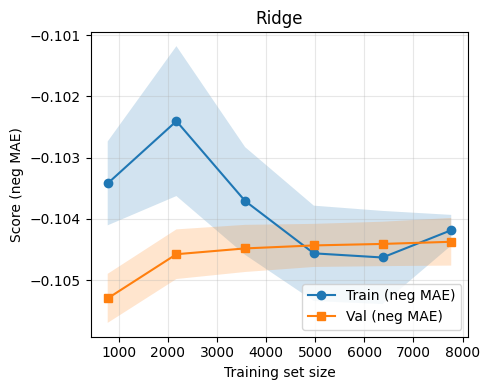

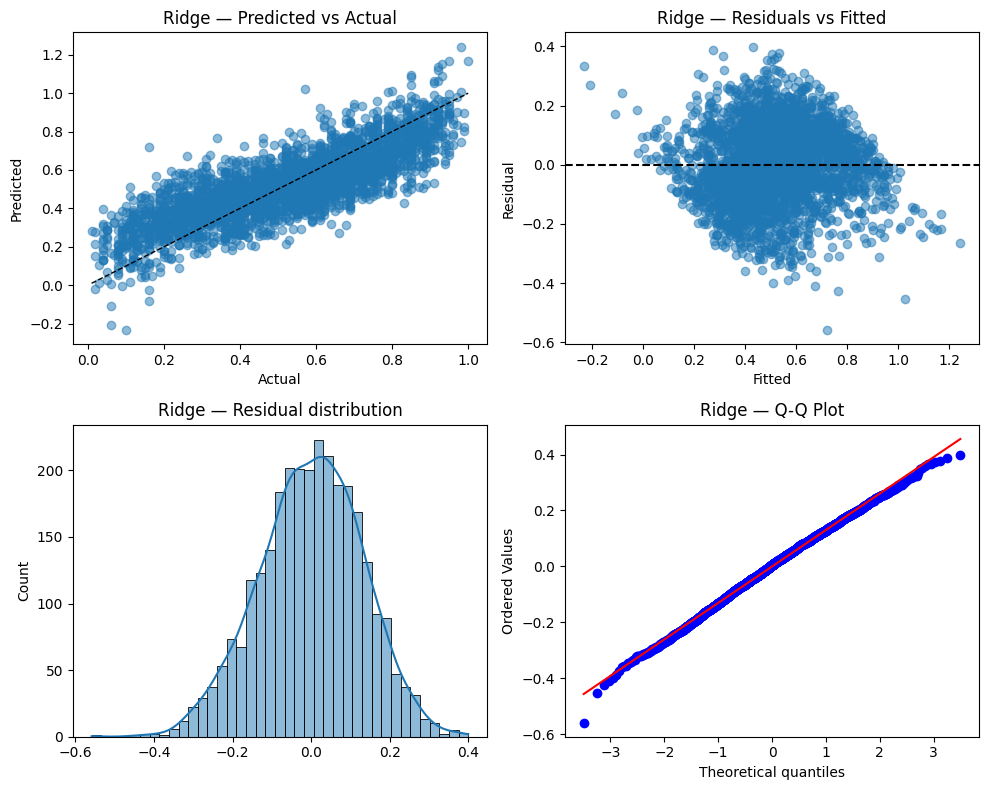

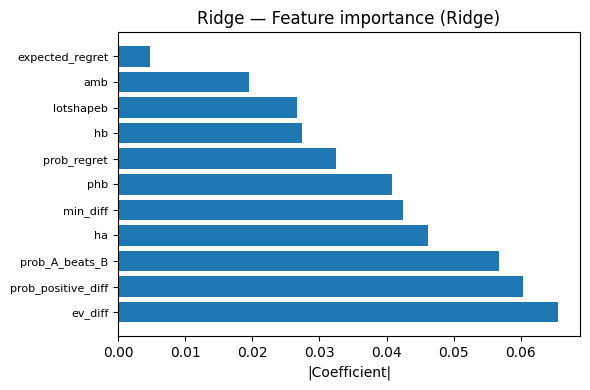

In [ ]:
model1 = Ridge(random_state=42)

params_optuna = {
    # log-scale is critical for alpha
    "alpha": ("float", 1e-4, 1e2, True),

    # categorical solver choice
    "solver": ("categorical", [
        "auto", "svd", "cholesky",
        "lsqr", "sparse_cg", "sag", "saga"
    ])
}

result1 = run_experiment(
    model1,
    X_eng, # use important features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance"],
    model_name="Ridge",
)

pipeline = result1.best_estimator
pred1 = result1.predictions
best_params1 = result1.best_params
metrics1 = result1.metrics


In [ ]:
# Ridge results: hyperparameters and test metrics
print("**Ridge results**")
print("Best hyperparameters:", result1.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics1["MAE"], metrics1["RMSE"], metrics1["MSE"], metrics1["R2"]))


**Ridge results**
Best hyperparameters: {'reg__alpha': 0.0003241647036554363, 'reg__solver': 'lsqr'}
Test metrics: MAE = 0.10472, RMSE = 0.13051, MSE = 0.01703, R2 = 0.65226


### Model: Ridge Regression


#### Performance (Test Set)
- **MAE:** 0.10472  
- **RMSE:** 0.13051  
- **MSE:** 0.01703  
- **R²:** 0.65226  

Best hyperparameters: `alpha = 3.24e-4`, solver `lsqr`

---

#### Generalization
Learning curves show close alignment between training and validation MAE, indicating stable generalization and low variance. Performance saturates smoothly, suggesting mildly bias-limited behavior consistent with a linear model.

---

#### Diagnostics
Predicted vs. actual values exhibit strong linear alignment, with slight compression at extreme probabilities.

---

#### Feature Effects
Largest coefficients correspond to engineered comparative features (`ev_diff`, `prob_positive_diff`, `prob_A_beats_B`, `min_diff`), while raw gamble descriptors receive lower weight. This supports the dominance of value and dominance-based signals in aggregate choice behavior.

---

### Random Forest

We train a Random Forest regressor. Key hyperparameters (e.g. number of trees, max depth, min samples per leaf) are tuned with Optuna.

[I 2026-02-07 02:18:06,088] A new study created in memory with name: no-name-040622e9-3450-43ac-ae8a-ac4f5de3e349


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-07 02:18:26,286] Trial 0 finished with value: -0.08246538251736794 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 0.8}. Best is trial 0 with value: -0.08246538251736794.
[I 2026-02-07 02:19:24,771] Trial 1 finished with value: -0.0841354089325554 and parameters: {'n_estimators': 450, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 0.8}. Best is trial 0 with value: -0.08246538251736794.
[I 2026-02-07 02:20:17,331] Trial 2 finished with value: -0.08857758082595936 and parameters: {'n_estimators': 400, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 1.0}. Best is trial 0 with value: -0.08246538251736794.
[I 2026-02-07 02:22:02,274] Trial 3 finished with value: -0.08113542083596563 and parameters: {'n_estimators': 550, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.8}. Best is trial 3 with value: -0.0811354208359

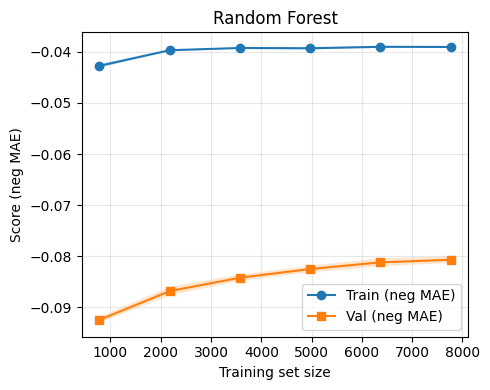

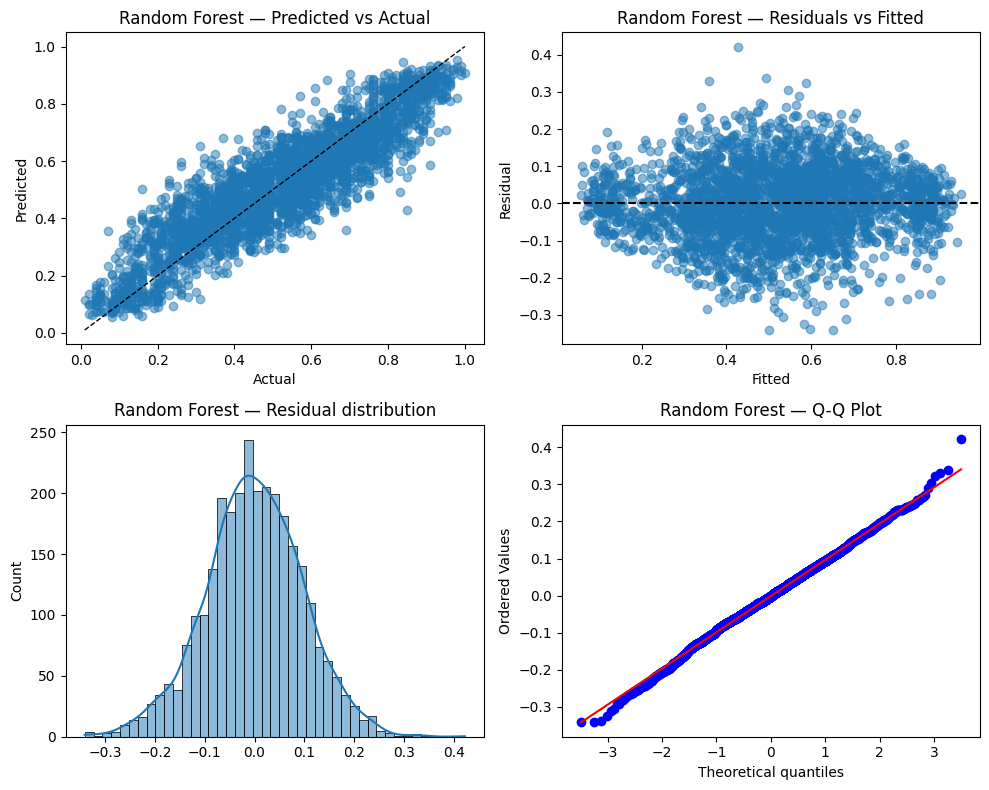

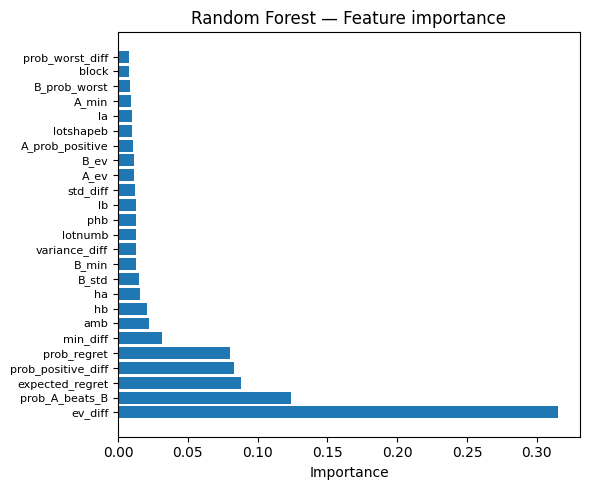

100%|===================| 199/200 [00:39<00:00]       

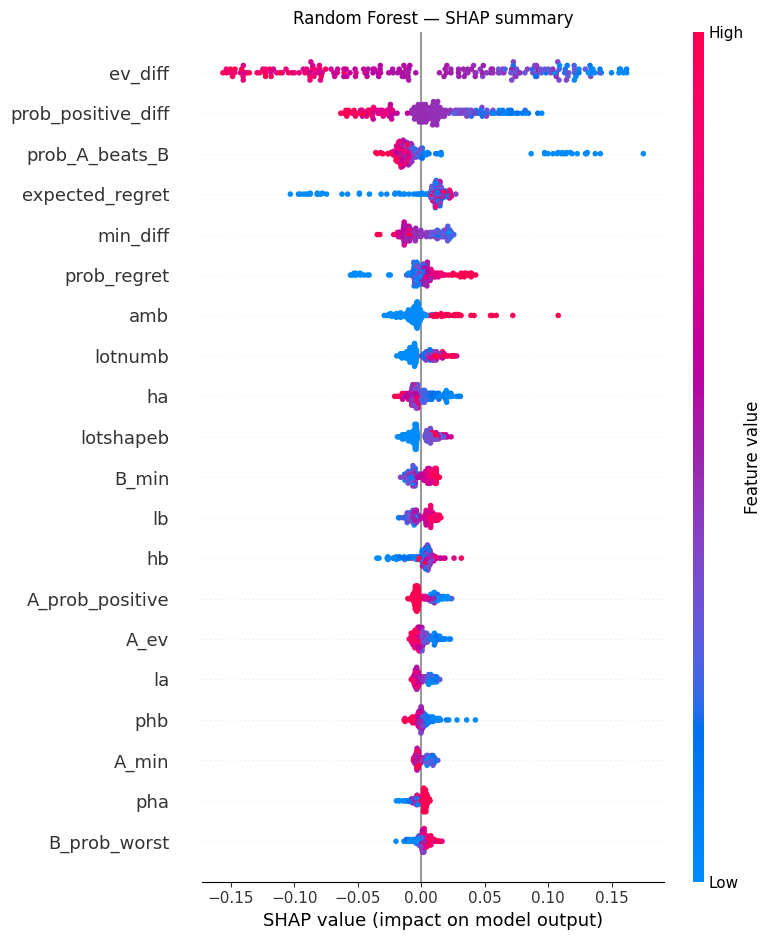

In [ ]:
model2 = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

params_optuna = {
    # trees: diminishing returns after ~400
    "n_estimators": ("int", 100, 600, False, 50),

    # depth: None often overfits → cap it
    "max_depth": ("int", 3, 30, False, 1),

    # regularization knobs (VERY important)
    "min_samples_split": ("int", 2, 20, False, 1),
    "min_samples_leaf": ("int", 1, 10, False, 1),

    # feature subsampling
    "max_features": ("categorical", ["sqrt", "log2", 0.5, 0.8, 1.0]),
}

result2 = run_experiment(
    model2,
    X, # regular features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,

    n_trials=40,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance", "shap"],
    model_name="Random Forest",
)

pipeline = result2.best_estimator
pred2 = result2.predictions
best_params2 = result2.best_params
metrics2 = result2.metrics


In [ ]:
# Random Forest results: hyperparameters and test metrics
print("**Random Forest results**")
print("Best hyperparameters:", result2.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics2["MAE"], metrics2["RMSE"], metrics2["MSE"], metrics2["R2"]))


**Random Forest results**
Best hyperparameters: {'reg__n_estimators': 250, 'reg__max_depth': 19, 'reg__min_samples_split': 5, 'reg__min_samples_leaf': 2, 'reg__max_features': 0.5}
Test metrics: MAE = 0.07694, RMSE = 0.09765, MSE = 0.00953, R2 = 0.80535


### Model: Random Forest Regressor


#### Performance (Test Set)
- **MAE:** 0.07694  
- **RMSE:** 0.09765  
- **MSE:** 0.00953  
- **R²:** 0.80535  

Best hyperparameters:
- `n_estimators = 250`, `max_depth = 19`
- `min_samples_split = 5`, `min_samples_leaf = 2`
- `max_features = 0.5`

---

#### Generalization
Learning curves show a persistent gap between training and validation MAE, indicating **moderate overfitting**, though validation performance improves steadily with more data. This reflects a **variance-sensitive but well-regularized** tree ensemble.

---

#### Diagnostics
Predicted vs. actual values align closely with the diagonal, especially in the mid-range, indicating strong predictive accuracy. Residuals are centered near zero with slightly increasing variance at higher fitted values. Residual distribution and Q–Q plots show mild tail deviations, consistent with non-linear modeling.

---

#### Feature Effects
Both impurity-based importance and SHAP analysis highlight:
- **Value and dominance signals:** `ev_diff`, `prob_positive_diff`, `prob_A_beats_B`
- **Risk and regret-related features:** `expected_regret`, `prob_regret`, `min_diff`

SHAP reveals clear **non-linear and asymmetric effects**, which are not captured by linear models.

---

#### Takeaway
Random Forest substantially outperforms linear baselines, explaining over **80% of the variance**. It captures complex, non-linear decision patterns at the cost of reduced interpretability and increased variance, making it a strong standalone model and a high-value ensemble component.


We can see that the random forest outperforms the Ridge Regression, with an MAE of 0.066

### Support Vector Regression (SVR)

We fit an SVR with RBF kernel. Optuna searches over regularization `C`, kernel coefficient, and `epsilon` in the epsilon-SVR formulation.

[I 2026-02-07 02:50:42,738] A new study created in memory with name: no-name-f577829c-20e9-4f45-b4e1-0ce7bcdbd346


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-07 02:50:57,054] Trial 0 finished with value: -0.0855436837139965 and parameters: {'kernel': 'rbf', 'C': 7.0025940438492125, 'epsilon': 0.09995018779523454, 'gamma': 0.09665055139462655}. Best is trial 0 with value: -0.0855436837139965.
[I 2026-02-07 02:51:01,827] Trial 1 finished with value: -0.10144278687788205 and parameters: {'kernel': 'rbf', 'C': 0.42294757032020847, 'epsilon': 0.12552427518677464, 'gamma': 0.001274764111550121}. Best is trial 0 with value: -0.0855436837139965.
[I 2026-02-07 02:51:17,604] Trial 2 finished with value: -0.08388701388208068 and parameters: {'kernel': 'rbf', 'C': 16.057004211006312, 'epsilon': 0.10466502893820995, 'gamma': 0.04234018489926236}. Best is trial 2 with value: -0.08388701388208068.
[I 2026-02-07 02:51:55,829] Trial 3 finished with value: -0.08307829899907991 and parameters: {'kernel': 'rbf', 'C': 12.972816300524293, 'epsilon': 0.026288868074644187, 'gamma': 0.04493372043623322}. Best is trial 3 with value: -0.08307829899907991.


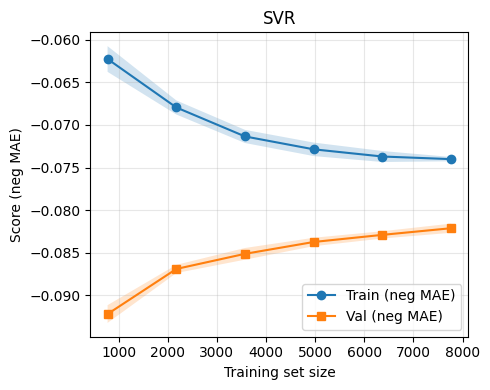

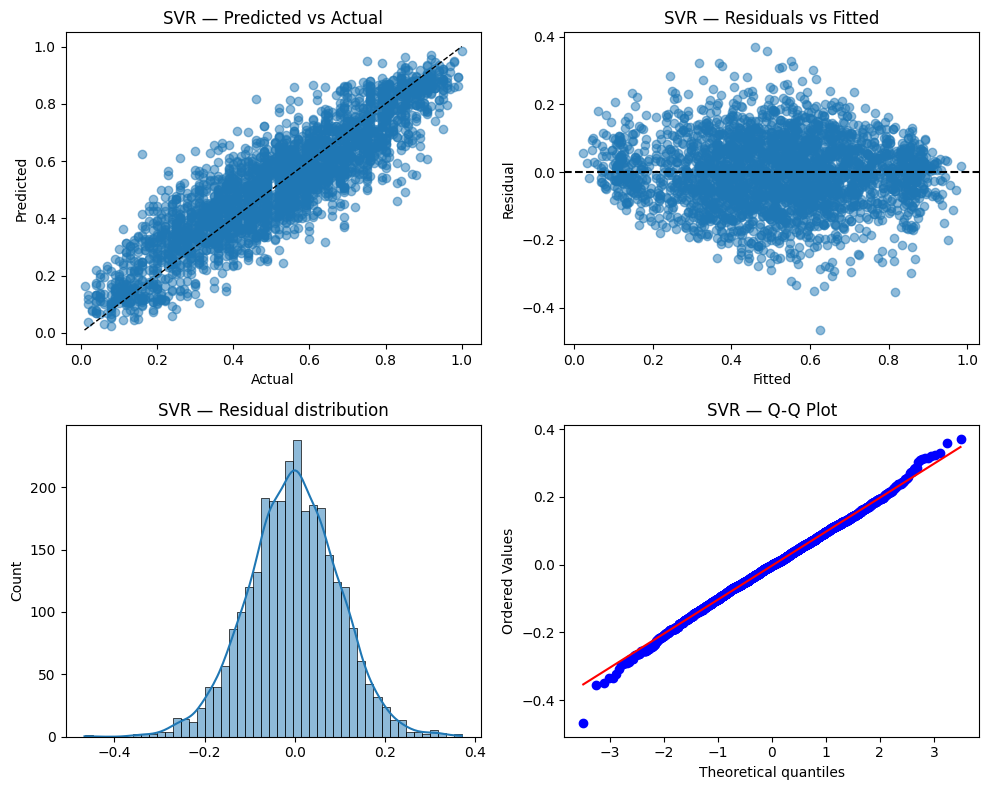

In [ ]:
model3 = SVR()

params_optuna = {
    "kernel": ("categorical", ["rbf"]),
    "C": ("float", 0.1, 30, True),
    "epsilon": ("float", 0.01, 0.3, True),
    "gamma": ("float", 1e-3, 0.2, True),
}

result3 = run_experiment(
    model3,
    X_eng, # important features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance"],
    model_name="SVR",
)

pipeline = result3.best_estimator
pred3 = result3.predictions
best_params3 = result3.best_params
metrics3 = result3.metrics



In [ ]:
# SVR results: hyperparameters and test metrics
print("**SVR results**")
print("Best hyperparameters:", result3.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics3["MAE"], metrics3["RMSE"], metrics3["MSE"], metrics3["R2"]))


**SVR results**
Best hyperparameters: {'reg__kernel': 'rbf', 'reg__C': 0.7205645342764099, 'reg__epsilon': 0.03168281078586778, 'reg__gamma': 0.07135005510668725}
Test metrics: MAE = 0.07889, RMSE = 0.10038, MSE = 0.01008, R2 = 0.79429


### Model: Support Vector Regression

**Task:** Predict aggregate choice probability (`brate`) on the 13k Choices dataset  
**Evaluation:** Cross-validated tuning with held-out test set

---

#### Performance (Test Set)
- **MAE:** 0.07889  
- **RMSE:** 0.10038  
- **MSE:** 0.01008  
- **R²:** 0.79429  

Best hyperparameters:
- Kernel: `RBF`
- `C = 0.721`, `epsilon = 0.0317`, `gamma = 0.0714`

---

#### Generalization
Learning curves show a consistent gap between training and validation MAE, indicating **moderate variance**. Validation performance improves steadily with more data, suggesting that the model benefits from larger sample sizes.

---

#### Diagnostics
Predicted vs. actual values show strong alignment with the diagonal, capturing non-linear structure beyond linear models. Residuals are centered near zero with mild heteroscedasticity at higher fitted values. Residual distribution is approximately symmetric, with slight tail deviations visible in the Q–Q plot.

---

#### Takeaway
SVR substantially improves over linear baselines and approaches Random Forest performance, capturing smooth non-linear decision patterns. However, it remains variance-sensitive and computationally heavier, making it best suited as a strong standalone non-linear model or an ensemble component.


### Gradient Boosting Regressor (GBR)

We use scikit-learn’s Gradient Boosting Regressor. Optuna tunes learning rate, number of estimators, max depth, and related parameters.

[I 2026-02-07 03:01:36,365] A new study created in memory with name: no-name-f3dfbfd8-8238-4273-ba28-5b5053493ba6


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-07 03:01:56,108] Trial 0 finished with value: -0.08010536912961361 and parameters: {'n_estimators': 250, 'learning_rate': 0.027848908635674616, 'max_depth': 4, 'subsample': 0.6318285066555587, 'min_samples_leaf': 15, 'min_samples_split': 46, 'max_features': None}. Best is trial 0 with value: -0.08010536912961361.
[I 2026-02-07 03:02:21,641] Trial 1 finished with value: -0.08382749935223084 and parameters: {'n_estimators': 150, 'learning_rate': 0.018122393345541606, 'max_depth': 6, 'subsample': 0.9422927733266904, 'min_samples_leaf': 7, 'min_samples_split': 21, 'max_features': None}. Best is trial 0 with value: -0.08010536912961361.
[I 2026-02-07 03:02:33,272] Trial 2 finished with value: -0.08953358423709458 and parameters: {'n_estimators': 650, 'learning_rate': 0.007431919974691081, 'max_depth': 3, 'subsample': 0.9717353165068057, 'min_samples_leaf': 4, 'min_samples_split': 13, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.08010536912961361.
[I 2026-02-07 03:02:38

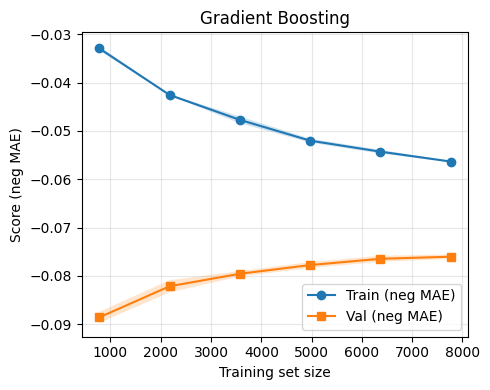

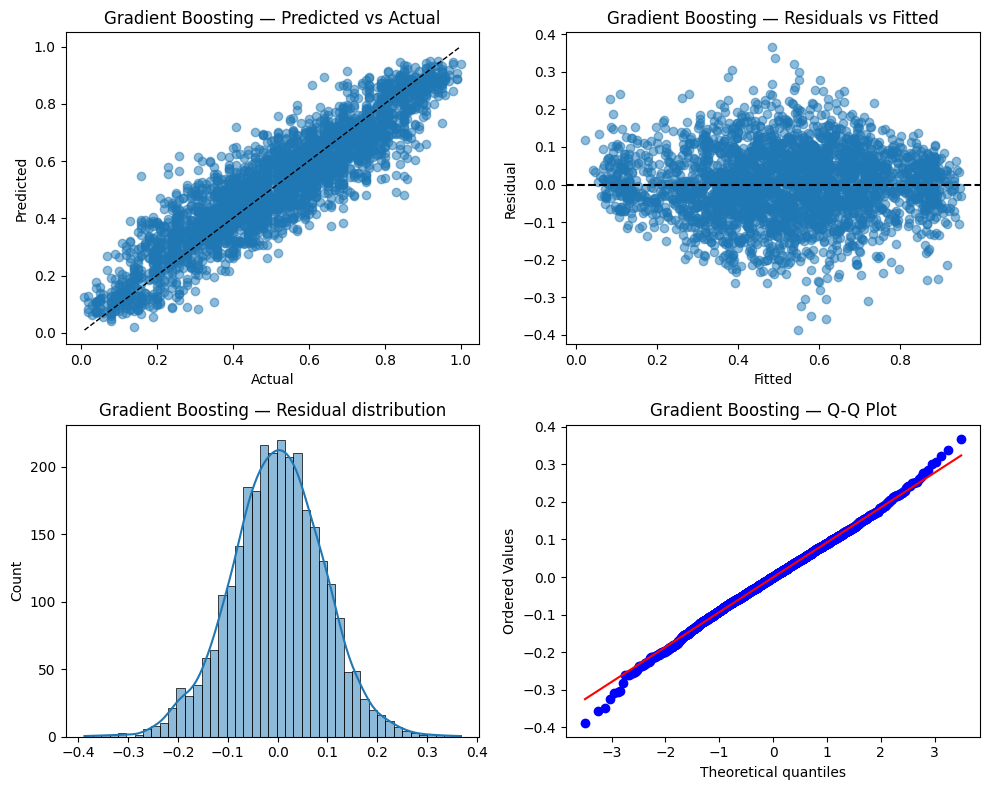

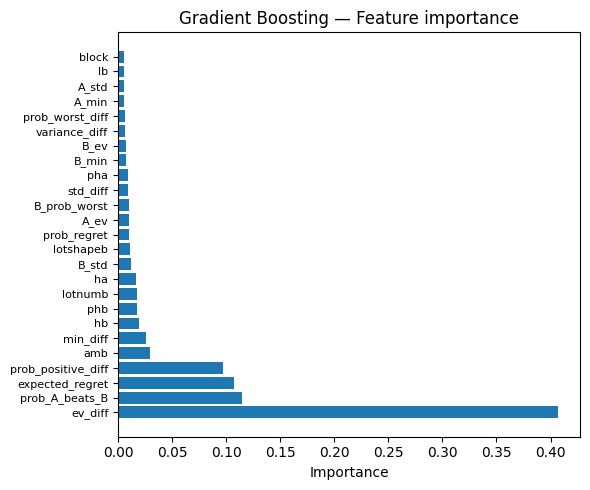

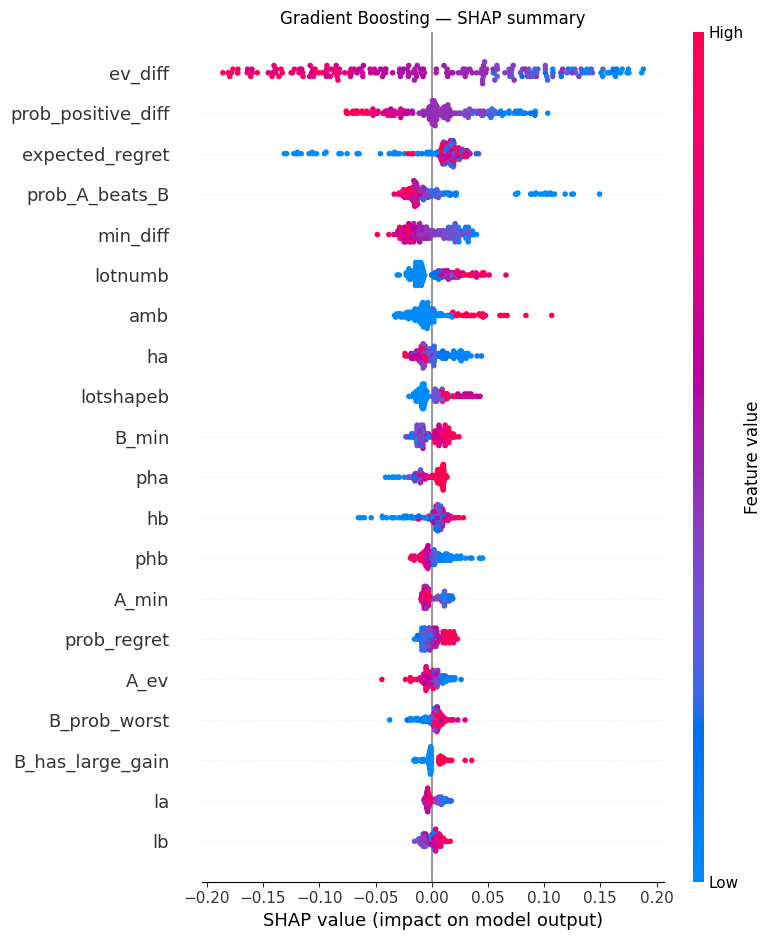

In [ ]:
model4 = GradientBoostingRegressor(random_state=42)

# Optuna search space (works with your run_experiment(search_engine="optuna") format)
params_optuna = {
    "n_estimators": ("int", 100, 800, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),   # log-scale
    "max_depth": ("int", 2, 6, False, 1),

    # very impactful for GBRT
    "subsample": ("float", 0.5, 1.0, False),
    "min_samples_leaf": ("int", 1, 20, False, 1),
    "min_samples_split": ("int", 2, 50, False, 1),

    # optional but useful
    "max_features": ("categorical", ["sqrt", "log2", None]),
}

result4 = run_experiment(
    model4,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance", "shap"],
    model_name="Gradient Boosting",
)

pipeline = result4.best_estimator
pred4 = result4.predictions
best_params4 = result4.best_params
metrics4 = result4.metrics


In [ ]:
# Gradient Boosting results: hyperparameters and test metrics
print("**Gradient Boosting results**")
print("Best hyperparameters:", result4.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics4["MAE"], metrics4["RMSE"], metrics4["MSE"], metrics4["R2"]))


**Gradient Boosting results**
Best hyperparameters: {'reg__n_estimators': 600, 'reg__learning_rate': 0.02141607945570896, 'reg__max_depth': 6, 'reg__subsample': 0.613017576894166, 'reg__min_samples_leaf': 11, 'reg__min_samples_split': 34, 'reg__max_features': None}
Test metrics: MAE = 0.07301, RMSE = 0.09283, MSE = 0.00862, R2 = 0.82407


### Model: Gradient Boosting Regressor

**Task:** Predict aggregate choice probability (`brate`) on the 13k Choices dataset  
**Evaluation:** Cross-validated tuning with held-out test set

---

#### Performance (Test Set)
- **MAE:** 0.07301  
- **RMSE:** 0.09283  
- **MSE:** 0.00862  
- **R²:** 0.82407  

Best hyperparameters:
- `n_estimators = 600`, `learning_rate = 0.0214`
- `max_depth = 6`, `subsample = 0.61`
- `min_samples_leaf = 11`, `min_samples_split = 34`

---

#### Generalization
Learning curves show a clear train–validation gap, indicating **controlled overfitting** typical of boosted trees. Validation performance improves steadily with more data, suggesting effective regularization via depth, subsampling, and leaf constraints.

---

#### Diagnostics
Predicted vs. actual values closely follow the diagonal, with improved calibration at the extremes compared to Random Forest and SVR. Residuals are centered near zero with mild heteroscedasticity; residual distribution and Q–Q plots show limited tail deviations.

---

#### Feature Effects
Both impurity-based importance and SHAP analysis identify:
- **Value and dominance signals:** `ev_diff`, `prob_positive_diff`, `prob_A_beats_B`
- **Regret and downside risk:** `expected_regret`, `min_diff`

SHAP reveals strong non-linear and asymmetric effects, particularly for value differences and probability dominance.

---

#### Takeaway
Gradient Boosting achieves the best overall performance among the evaluated models, explaining over **82% of the variance**. It effectively captures complex, non-linear decision patterns while remaining reasonably well-regularized, making it a strong candidate for the final model.


### Stacking (Ridge + RF + GBR + SVR)

A first stacking ensemble: base learners are Ridge, Random Forest, Gradient Boosting, and SVR (using their best-tuned pipelines). A meta-learner combines their predictions; we use cross-validation to generate meta-features.

[I 2026-02-07 03:18:44,365] A new study created in memory with name: no-name-f1ad4bf5-80a5-4aae-a7ec-9a658a2117b2


Using 4661/11654 samples for tuning...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-02-07 03:19:57,232] Trial 0 finished with value: -0.08385930011034 and parameters: {'rf__n_estimators': 350, 'rf__max_depth': 25, 'rf__min_samples_leaf': 8, 'rf__max_features': 0.8, 'svr__C': 24.801934086945888, 'svr__epsilon': 0.03811836024657915, 'svr__gamma': 0.011603371094415626, 'gbr__n_estimators': 400, 'gbr__learning_rate': 0.0731726663792282, 'gbr__max_depth': 2, 'gbr__subsample': 0.645774576270041, 'final_estimator__alpha': 0.00635801590121652}. Best is trial 0 with value: -0.08385930011034.
[I 2026-02-07 03:21:04,024] Trial 1 finished with value: -0.08523120126823173 and parameters: {'rf__n_estimators': 500, 'rf__max_depth': 19, 'rf__min_samples_leaf': 2, 'rf__max_features': 'sqrt', 'svr__C': 0.40694382812742047, 'svr__epsilon': 0.022045125407865004, 'svr__gamma': 0.0015044738912024485, 'gbr__n_estimators': 450, 'gbr__learning_rate': 0.024723431285374207, 'gbr__max_depth': 2, 'gbr__subsample': 0.7606250559958276, 'final_estimator__alpha': 0.0013884969491292627}. Best 

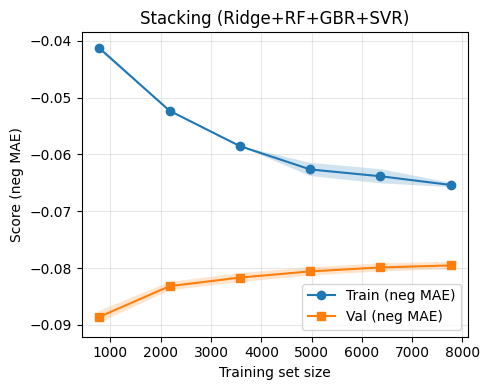

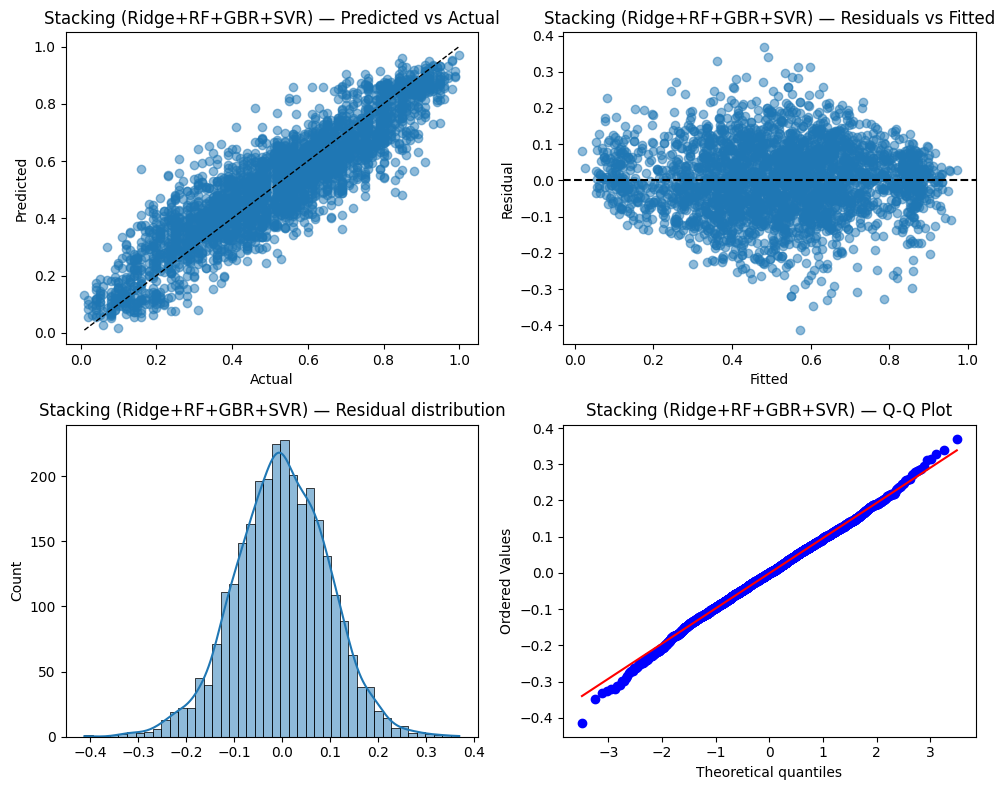

In [ ]:
model7 = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
        ("svr", SVR(kernel="rbf")),
        ("gbr", GradientBoostingRegressor(random_state=42)),
    ],
    final_estimator=Ridge(random_state=42),
    cv=5,
    n_jobs=-1
)

params_optuna = {
    # --- RF ---
    "rf__n_estimators": ("int", 100, 500, False, 50),
    "rf__max_depth": ("int", 3, 25, False, 1),
    "rf__min_samples_leaf": ("int", 1, 8, False, 1),
    "rf__max_features": ("categorical", ["sqrt", "log2", 0.5, 0.8]),

    # --- SVR ---
    "svr__C": ("float", 0.1, 30, True),
    "svr__epsilon": ("float", 0.01, 0.3, True),
    "svr__gamma": ("float", 1e-3, 0.2, True),

    # --- GBRT ---
    "gbr__n_estimators": ("int", 50, 500, False, 50),
    "gbr__learning_rate": ("float", 1e-2, 3e-1, True),
    "gbr__max_depth": ("int", 2, 5, False, 1),
    "gbr__subsample": ("float", 0.6, 1.0, False),

    # --- final ridge ---
    "final_estimator__alpha": ("float", 1e-4, 1e2, True),
}

result7 = run_experiment(
    model7,
    X_eng,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    sample_size=0.4,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance"],
    model_name="Stacking (Ridge+RF+GBR+SVR)",
)

pipeline = result7.best_estimator
pred7 = result7.predictions
best_params7 = result7.best_params
metrics7 = result7.metrics

In [ ]:
# First stacking (Ridge+RF+GBR+SVR) results: hyperparameters and test metrics
print("**First stacking (Ridge+RF+GBR+SVR) results**")
print("Best hyperparameters:", result7.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics7["MAE"], metrics7["RMSE"], metrics7["MSE"], metrics7["R2"]))


**First stacking (Ridge+RF+GBR+SVR) results**
Best hyperparameters: {'reg__rf__n_estimators': 250, 'reg__rf__max_depth': 16, 'reg__rf__min_samples_leaf': 2, 'reg__rf__max_features': 'sqrt', 'reg__svr__C': 13.36341373559243, 'reg__svr__epsilon': 0.017909942212744723, 'reg__svr__gamma': 0.03851756313589188, 'reg__gbr__n_estimators': 350, 'reg__gbr__learning_rate': 0.02652109935299212, 'reg__gbr__max_depth': 5, 'reg__gbr__subsample': 0.8953336172085298, 'reg__final_estimator__alpha': 0.000682349940077629}
Test metrics: MAE = 0.07644, RMSE = 0.09701, MSE = 0.00941, R2 = 0.80787


**Comment:** Stacking combines Ridge, RF, GBR, and SVR so the meta-learner can weight their predictions. If test MAE is better than the best single model, the base learners are complementary; otherwise a single strong model may suffice.

### XGBoost

We train an XGBoost regressor with Optuna tuning (e.g. learning rate, max depth, number of estimators, subsample, colsample). The tree method is set for efficient CPU training.

[I 2026-02-07 04:02:11,681] A new study created in memory with name: no-name-a778de90-756d-4a26-93b2-d550f26febcb


Using 5827/11654 samples for tuning...


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-07 04:02:13,219] Trial 0 finished with value: -0.09645606706078148 and parameters: {'n_estimators': 700, 'learning_rate': 0.006826941948711544, 'max_depth': 2, 'subsample': 0.8671178601218539, 'colsample_bytree': 0.6331494023927465, 'min_child_weight': 18.111452084611074, 'reg_alpha': 0.008208500299879077, 'reg_lambda': 6.249366020329343, 'gamma': 2.518729574172855e-07}. Best is trial 0 with value: -0.09645606706078148.
[I 2026-02-07 04:02:16,765] Trial 1 finished with value: -0.12999789754586763 and parameters: {'n_estimators': 650, 'learning_rate': 0.0011517650340138509, 'max_depth': 5, 'subsample': 0.610642901873448, 'colsample_bytree': 0.8417889660677758, 'min_child_weight': 1.151595233706708, 'reg_alpha': 0.009424557346006706, 'reg_lambda': 18.05970824924955, 'gamma': 4.3763072888659065e-05}. Best is trial 0 with value: -0.09645606706078148.
[I 2026-02-07 04:02:38,426] Trial 2 finished with value: -0.07862454966004916 and parameters: {'n_estimators': 1500, 'learning_rat

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2026-02-07 04:03:07,065] Trial 6 finished with value: -0.10224312394551156 and parameters: {'n_estimators': 850, 'learning_rate': 0.0016372777713898946, 'max_depth': 10, 'subsample': 0.9004546933998404, 'colsample_bytree': 0.9739286042592563, 'min_child_weight': 7.407141882550695, 'reg_alpha': 0.0006589543484810012, 'reg_lambda': 14.03876543362279, 'gamma': 0.00042709797250864613}. Best is trial 2 with value: -0.07862454966004916.
[I 2026-02-07 04:03:13,493] Trial 7 finished with value: -0.08001296729113967 and parameters: {'n_estimators': 1500, 'learning_rate': 0.03940748433652276, 'max_depth': 4, 'subsample': 0.7479291956341011, 'colsample_bytree': 0.8176523763367078, 'min_child_weight': 7.6105156915282315, 'reg_alpha': 2.365499547982324e-06, 'reg_lambda': 0.06257877321109276, 'gamma': 0.0002860438902077451}. Best is trial 2 with value: -0.07862454966004916.
[I 2026-02-07 04:03:21,192] Trial 8 finished with value: -0.07947446757489436 and parameters: {'n_estimators': 700, 'learnin

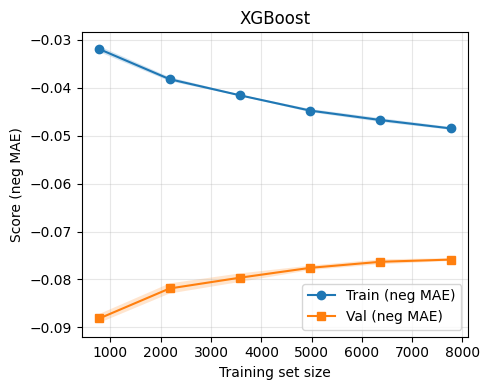

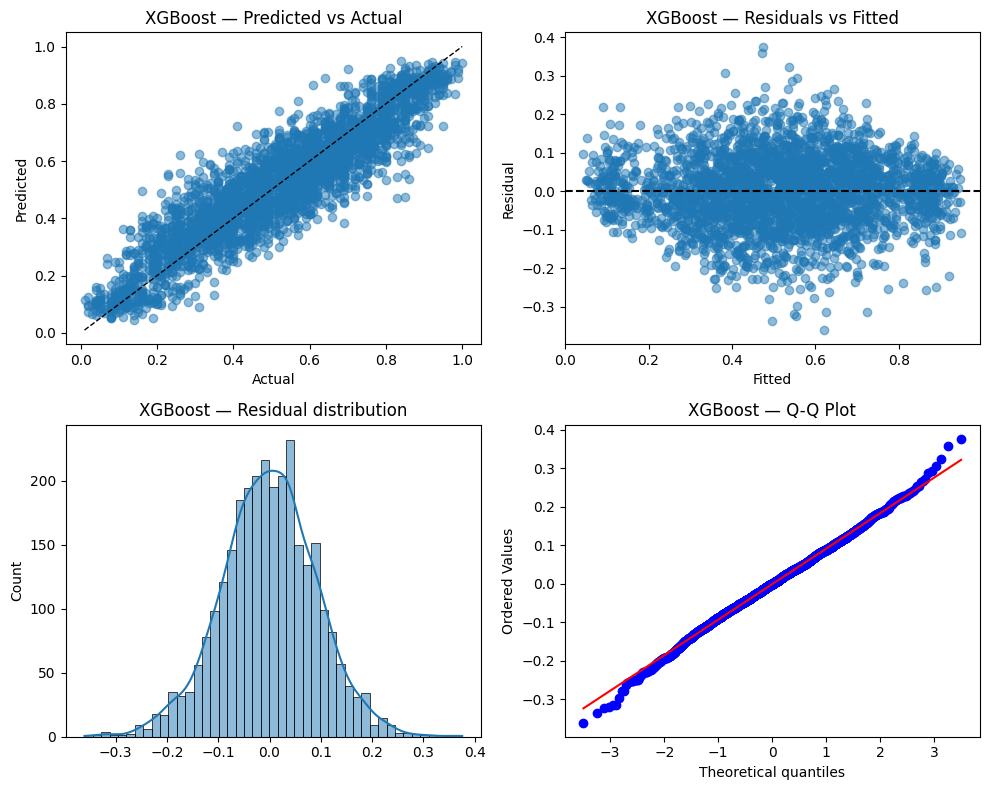

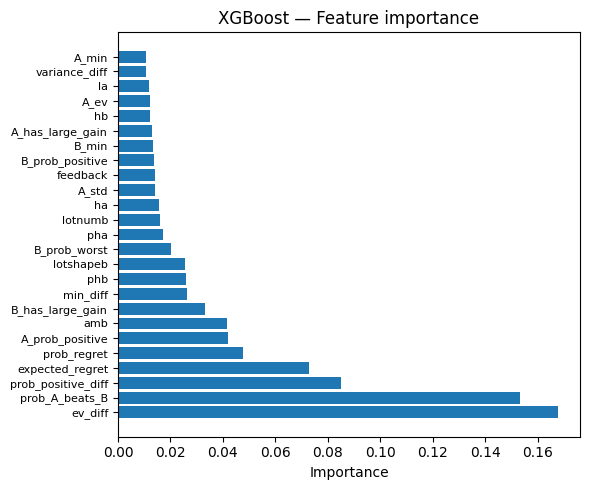

 98%|===================| 197/200 [00:25<00:00]       

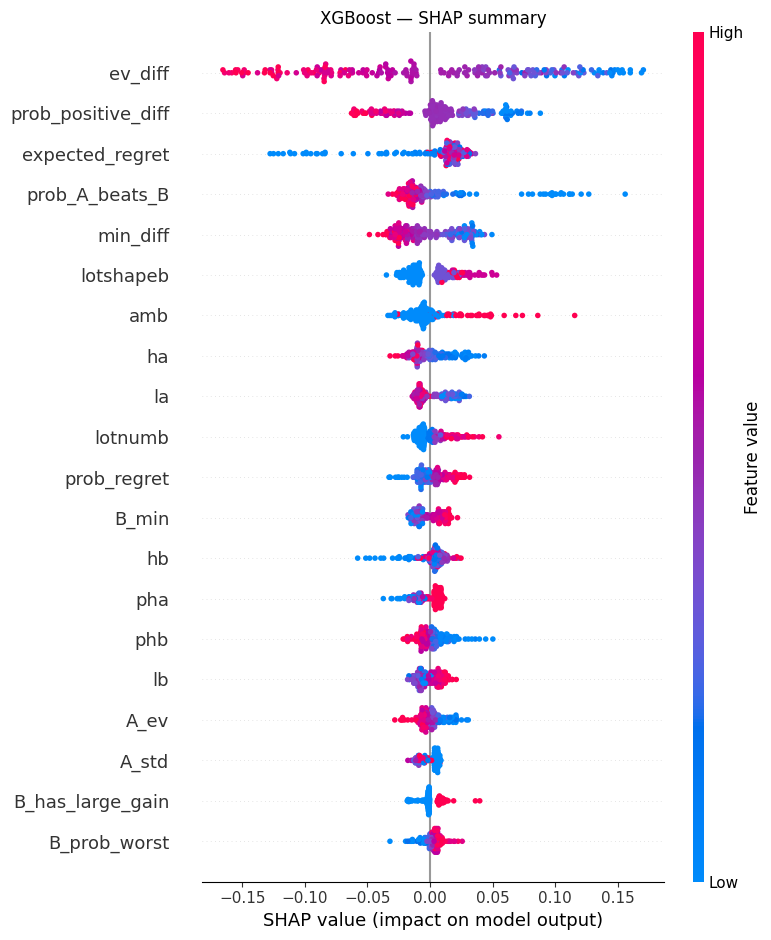

In [ ]:
xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method="hist"   # much faster on CPU
)

# Optuna search space (compatible with your run_experiment(..., search_engine="optuna"))
params_optuna = {
    # core
    "n_estimators": ("int", 200, 1500, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),
    "max_depth": ("int", 2, 10, False, 1),

    # regularization / robustness (big wins)
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),
    "min_child_weight": ("float", 1.0, 20.0, True),
    "reg_alpha": ("float", 1e-8, 1.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    # optional but often helpful
    "gamma": ("float", 1e-8, 5.0, True),
}

result8 = run_experiment(
    xgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5,   # optional speed-up; remove if you want full data tuning
    plots=["learning_curve", "diagnostics_4panel", "feature_importance", "shap"],
    model_name="XGBoost",
)

pipeline = result8.best_estimator
pred8 = result8.predictions
best_params8 = result8.best_params
metrics8 = result8.metrics


In [ ]:

print("**XGBoost results**")
print("Best hyperparameters:", result8.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics8["MAE"], metrics8["RMSE"], metrics8["MSE"], metrics8["R2"]))


**XGBoost results**
Best hyperparameters: {'reg__n_estimators': 1100, 'reg__learning_rate': 0.008915696977461923, 'reg__max_depth': 8, 'reg__subsample': 0.8105672090198429, 'reg__colsample_bytree': 0.7619060568991234, 'reg__min_child_weight': 17.65216376530959, 'reg__reg_alpha': 0.0004897332342688666, 'reg__reg_lambda': 0.043247768156536866, 'reg__gamma': 7.243179070033534e-05}
Test metrics: MAE = 0.07242, RMSE = 0.09227, MSE = 0.00851, R2 = 0.82619


### Model: XGBoost Regressor

**Task:** Predict aggregate choice probability (`brate`) on the 13k Choices dataset  
**Evaluation:** Cross-validated tuning with held-out test set

---

#### Performance (Test Set)
- **MAE:** 0.07242  
- **RMSE:** 0.09227  
- **MSE:** 0.00851  
- **R²:** 0.82619  

Best hyperparameters:
- `n_estimators = 1100`, `learning_rate = 0.0089`
- `max_depth = 8`, `min_child_weight = 17.65`
- `subsample = 0.81`, `colsample_bytree = 0.76`
- `reg_alpha = 4.9e-4`, `reg_lambda = 0.043`

---

#### Generalization
Learning curves indicate controlled overfitting with a stable train–validation gap. Validation error improves steadily with additional data, suggesting effective regularization despite model depth.

---

#### Diagnostics
Predicted vs. actual values closely follow the diagonal, with improved calibration at extreme probabilities relative to Random Forest and SVR. Residuals are centered near zero with mild heteroscedasticity; residual distribution and Q–Q plots show limited tail deviations.

---

#### Feature Effects
Both gain-based importance and SHAP analysis identify:
- **Value and dominance:** `ev_diff`, `prob_positive_diff`, `prob_A_beats_B`
- **Regret and downside risk:** `expected_regret`, `min_diff`, `prob_regret`

SHAP reveals strong non-linear and asymmetric effects, particularly for value differences.

---

#### Takeaway
XGBoost achieves the strongest overall performance among all evaluated models, explaining over **82% of the variance**. It combines high predictive accuracy with robust regularization, making it the best standalone model and a strong benchmark for subsequent analyses.


### LightGBM

We fit a LightGBM regressor with Optuna tuning. LightGBM often trains quickly and can perform well on tabular data.

[I 2026-02-07 04:10:40,999] A new study created in memory with name: no-name-27ee849e-19f8-4870-af27-03d79725a84a


Using 5827/11654 samples for tuning...


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-07 04:10:56,146] Trial 0 finished with value: -0.12204752589079075 and parameters: {'learning_rate': 0.0011613608238319419, 'n_estimators': 800, 'num_leaves': 214, 'max_depth': 14, 'min_child_samples': 27, 'subsample': 0.9566066898505893, 'colsample_bytree': 0.6728981819802363, 'reg_alpha': 0.5026302939378656, 'reg_lambda': 27.638284095471327, 'min_split_gain': 5.17331036441072e-07}. Best is trial 0 with value: -0.12204752589079075.
[I 2026-02-07 04:11:22,223] Trial 1 finished with value: -0.10003925717152451 and parameters: {'learning_rate': 0.0010073298157176917, 'n_estimators': 1400, 'num_leaves': 51, 'max_depth': 15, 'min_child_samples': 42, 'subsample': 0.6380118450242251, 'colsample_bytree': 0.6497486691961017, 'reg_alpha': 5.0323781176663075e-08, 'reg_lambda': 0.05028403547169364, 'min_split_gain': 3.7208105517039584e-05}. Best is trial 1 with value: -0.10003925717152451.
[I 2026-02-07 04:11:48,568] Trial 2 finished with value: -0.07936387835976332 and parameters: {'l

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 0.07276649198736451
RMSE: 0.09239972444016926
MSE: 0.008537709076619214
R^2: 0.8257002814420803


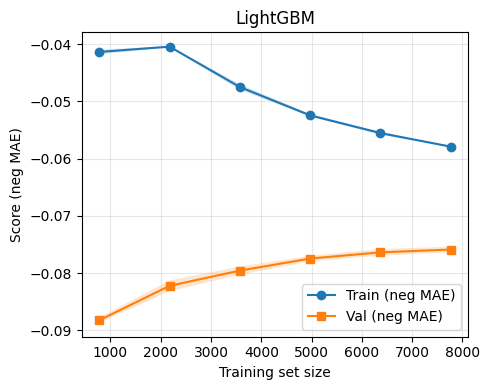

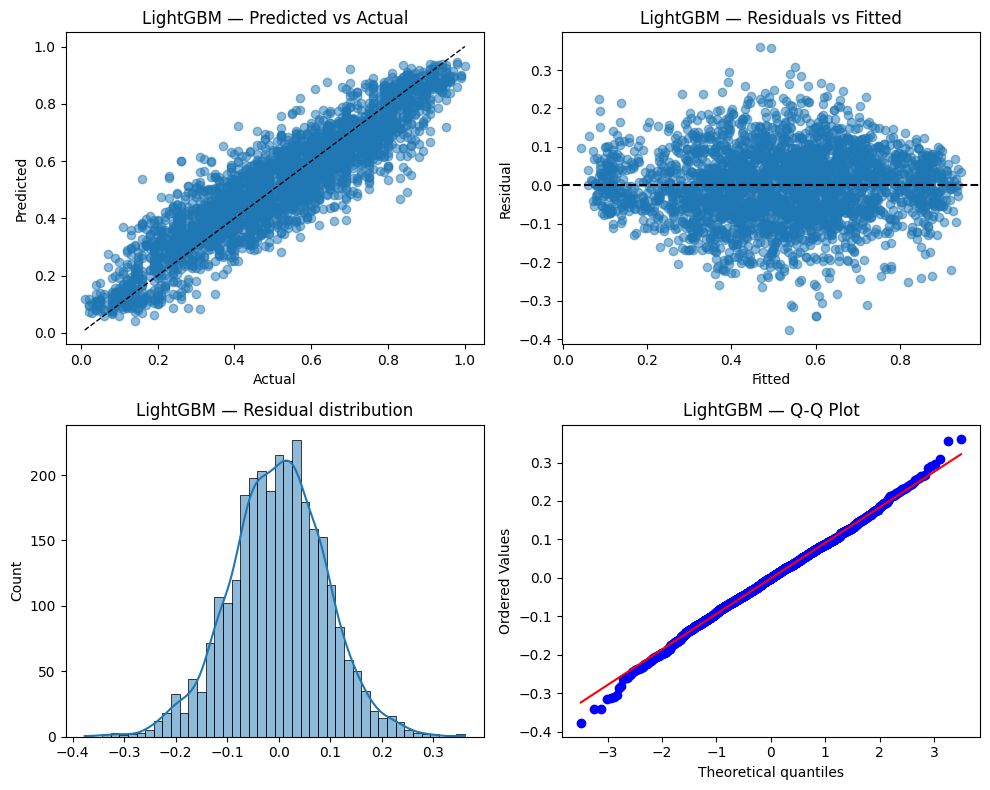

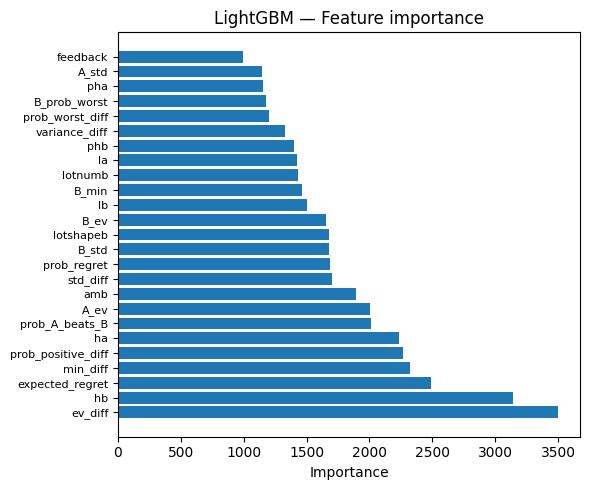

 98%|===================| 197/200 [00:16<00:00]       

SHAP skipped: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.332150, while the model output was 0.385990. If this difference is acceptable you can set check_additivity=False to disable this check.


In [ ]:
lgb = LGBMRegressor(
    random_state=42,
    n_jobs=-1
)

# Optuna search space (compatible with your run_experiment(..., search_engine="optuna"))
params_optuna = {
    # core
    "learning_rate": ("float", 1e-3, 2e-1, True),
    "n_estimators": ("int", 200, 4000, False, 100),

    # tree shape / capacity
    "num_leaves": ("int", 16, 256, True),        # log-ish effect
    "max_depth": ("int", -1, 16, False, 1),      # -1 means no limit
    "min_child_samples": ("int", 5, 120, False, 1),

    # sampling (regularization)
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),

    # regularization
    "reg_alpha": ("float", 1e-8, 10.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    # optional but often helpful on noisy data
    "min_split_gain": ("float", 1e-8, 1.0, True),
}

result9 = run_experiment(
    lgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5,  # optional speed-up; remove if you want full-data tuning
    plots=["learning_curve", "diagnostics_4panel", "feature_importance", "shap"],
    model_name="LightGBM",
)

pipeline = result9.best_estimator
pred9 = result9.predictions
best_params9 = result9.best_params
metrics9 = result9.metrics


In [ ]:
# LightGBM results: hyperparameters and test metrics
print("**LightGBM results**")
print("Best hyperparameters:", result9.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics9["MAE"], metrics9["RMSE"], metrics9["MSE"], metrics9["R2"]))


**LightGBM results**
Best hyperparameters: {'reg__learning_rate': 0.007461421395813948, 'reg__n_estimators': 1000, 'reg__num_leaves': 50, 'reg__max_depth': 16, 'reg__min_child_samples': 28, 'reg__subsample': 0.6499052008270234, 'reg__colsample_bytree': 0.6362283879012286, 'reg__reg_alpha': 7.4914973216918295e-06, 'reg__reg_lambda': 0.08450719183374401, 'reg__min_split_gain': 3.301840278313878e-07}
Test metrics: MAE = 0.07277, RMSE = 0.09240, MSE = 0.00854, R2 = 0.82570


### Model: LightGBM Regressor

**Task:** Predict aggregate choice probability (`brate`) on the 13k Choices dataset  
**Evaluation:** Cross-validated tuning with held-out test set

---

#### Performance (Test Set)
- **MAE:** 0.07277  
- **RMSE:** 0.09240  
- **MSE:** 0.00854  
- **R²:** 0.82570  

Best hyperparameters:
- `learning_rate = 0.0075`, `n_estimators = 1000`
- `num_leaves = 50`, `max_depth = 16`
- `subsample = 0.65`, `colsample_bytree = 0.64`
- `reg_lambda = 0.0845`

---

#### Generalization
Learning curves show a stable train–validation gap, indicating **controlled overfitting**. Validation performance improves smoothly with increasing data, consistent with effective regularization despite model complexity.

---

#### Diagnostics
Predicted vs. actual values closely align with the diagonal, with good calibration across the full probability range. Residuals are centered near zero with mild heteroscedasticity; residual distribution and Q–Q plots show limited tail deviations.

---

#### Feature Effects
Gain-based importance highlights:
- **Value and dominance:** `ev_diff`, `expected_regret`, `prob_positive_diff`, `prob_A_beats_B`
- **Risk-related features:** `min_diff`, `amb`, `std_diff`

The importance pattern closely mirrors Gradient Boosting and XGBoost.

---

#### Takeaway
LightGBM matches XGBoost performance, explaining over **82% of the variance**. It offers an excellent accuracy–efficiency trade-off and is well suited as a final model or as part of an ensemble.


### Second stacking (XGB + LightGBM + Ridge)

A second stacking ensemble using the best-tuned XGBoost, LightGBM, and Ridge as base learners. The meta-learner is tuned (e.g. via Optuna) on the stacking pipeline.

[I 2026-02-07 04:30:54,344] A new study created in memory with name: no-name-99872949-07f2-45c7-92d7-271881fe8d32


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-02-07 04:32:41,931] Trial 0 finished with value: -0.07580113282388454 and parameters: {'final_estimator__alpha': 15.527958794668137, 'final_estimator__fit_intercept': True, 'passthrough': False}. Best is trial 0 with value: -0.07580113282388454.


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2026-02-07 04:35:35,360] Trial 1 finished with value: -0.07555995060218033 and parameters: {'final_estimator__alpha': 0.014132152851001566, 'final_estimator__fit_intercept': True, 'passthrough': False}. Best is trial 1 with value: -0.07555995060218033.
[I 2026-02-07 04:37:22,607] Trial 2 finished with value: -0.0755599163187941 and parameters: {'final_estimator__alpha': 0.00035379423564539783, 'final_estimator__fit_intercept': True, 'passthrough': False}. Best is trial 2 with value: -0.0755599163187941.
[I 2026-02-07 04:39:11,251] Trial 3 finished with value: -0.07555991556963175 and parameters: {'final_estimator__alpha': 1.4034508766933758e-06, 'final_estimator__fit_intercept': True, 'passthrough': False}. Best is trial 3 with value: -0.07555991556963175.
[I 2026-02-07 04:40:56,915] Trial 4 finished with value: -0.07555992055071598 and parameters: {'final_estimator__alpha': 0.00232572850321301, 'final_estimator__fit_intercept': True, 'passthrough': False}. Best is trial 3 with valu

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 0.07228047564719081
RMSE: 0.0920731909301908
MSE: 0.00847747248806737
R^2: 0.8269300282438574


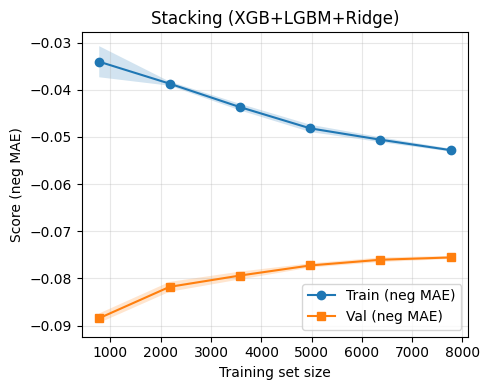

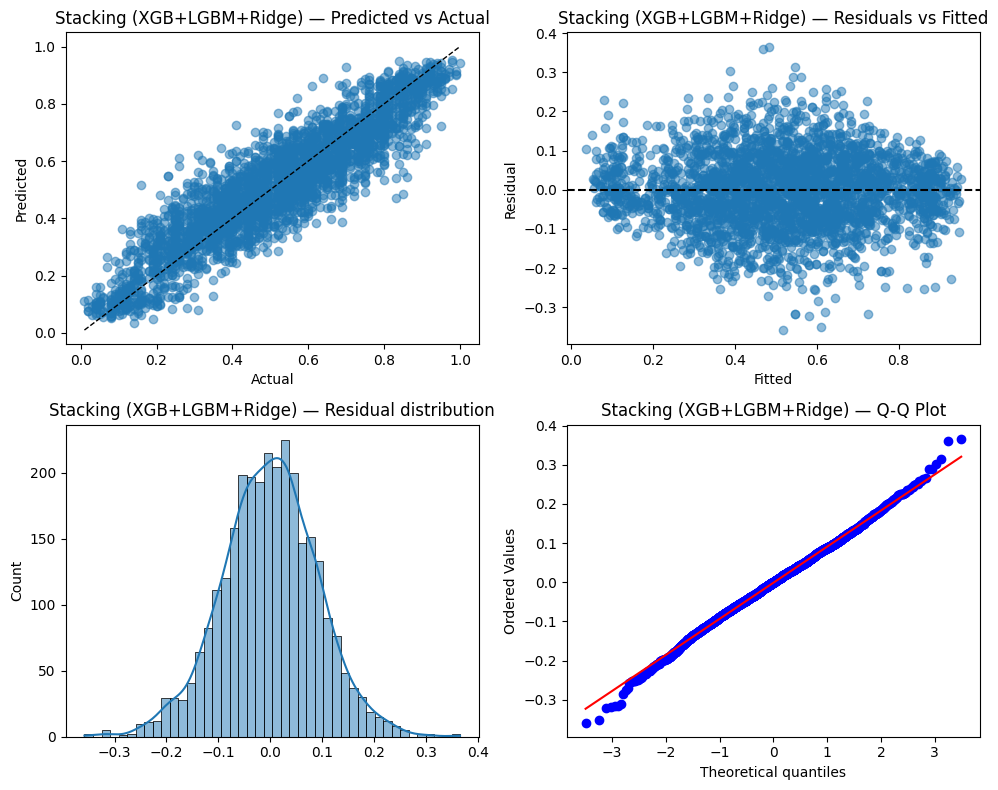

In [ ]:
estimators = [
    ("xgb", result8.best_estimator.named_steps["reg"]),
    ("lgb", result9.best_estimator.named_steps["reg"]),
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(random_state=42),
    cv=3,          # tune with 3 for speed; set to 5 for final refit
    n_jobs=-1
)

params_optuna = {
    "final_estimator__alpha": ("float", 1e-6, 1e2, True),
    "final_estimator__fit_intercept": ("categorical", [True, False]),
    "passthrough": ("categorical", [False, True]),
}

result10 = run_experiment(
    stack,
    X, y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance"],
    model_name="Stacking (XGB+LGBM+Ridge)",
)

pipeline = result10.best_estimator
pred10 = result10.predictions
best_params10 = result10.best_params
metrics10 = result10.metrics


In [ ]:
# Second stacking (XGB+LGBM+Ridge) results: hyperparameters and test metrics
print("**Second stacking (XGB+LGBM+Ridge) results**")
print("Best hyperparameters:", result10.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics10["MAE"], metrics10["RMSE"], metrics10["MSE"], metrics10["R2"]))
print("Compare MAE with the first stacking and single models.")


**Second stacking (XGB+LGBM+Ridge) results**
Best hyperparameters: {'reg__final_estimator__alpha': 1.092046085049222e-06, 'reg__final_estimator__fit_intercept': True, 'reg__passthrough': False}
Test metrics: MAE = 0.07228, RMSE = 0.09207, MSE = 0.00848, R2 = 0.82693
Compare MAE with the first stacking and single models.


### Model: Stacking Regressor (XGBoost + LightGBM + Ridge)

**Task:** Predict aggregate choice probability (`brate`) on the 13k Choices dataset  
**Evaluation:** Cross-validated stacking with held-out test set

---

#### Performance (Test Set)
- **MAE:** 0.07228  
- **RMSE:** 0.09207  
- **MSE:** 0.00848  
- **R²:** 0.82693  

Meta-learner: Ridge regression (`alpha = 1.09e-6`)

---

#### Results and Comparison
The stacking model achieves the **lowest MAE across all evaluated approaches**, marginally improving upon the best single models (XGBoost and LightGBM). The gain over XGBoost alone is small, indicating that most predictive structure is already captured by strong gradient-boosted trees.

---

#### Interpretation
The improvement suggests **complementarity between XGBoost and LightGBM**, with the Ridge meta-learner effectively combining their predictions while reducing variance. However, the limited magnitude of the gain indicates diminishing returns from ensembling at this stage.

---

#### Takeaway
Stacking provides the best overall predictive performance, but only a **modest improvement** over the strongest single models. Given the added complexity, it is best justified when marginal accuracy gains are critical; otherwise, XGBoost or LightGBM alone offer a near-optimal and simpler alternative.

In [ ]:
rows = []

if "metrics1" in globals():
    rows.append({"model": "model1_ridge", "MAE": metrics1["MAE"]})
if "metrics2" in globals():
    rows.append({"model": "model2_rf", "MAE": metrics2["MAE"]})
if "metrics3" in globals():
    rows.append({"model": "model3_svr", "MAE": metrics3["MAE"]})
if "metrics4" in globals():
    rows.append({"model": "model4_gbr", "MAE": metrics4["MAE"]})
if "metrics7" in globals():
    rows.append({"model": "model7_stack", "MAE": metrics7["MAE"]})
if "metrics8" in globals():
    rows.append({"model": "model8_xgb", "MAE": metrics8["MAE"]})
if "metrics9" in globals():
    rows.append({"model": "model9_lgbm", "MAE": metrics9["MAE"]})
if "metrics10" in globals():
    rows.append({"model": "model10_stack2", "MAE": metrics10["MAE"]})

if not rows:
    print("No metrics objects (metrics1, metrics2, ...) found. Run the model cells first.")
else:
    mae_df = pd.DataFrame(rows)
    mae_df = mae_df.sort_values("MAE").reset_index(drop=True)

    print("MAE per non-NN model (sorted, lower is better):")
    display(mae_df.style.format({"MAE": "{:.6f}"}))

MAE per non-NN model (sorted, lower is better):


,model,MAE
0,model10_stack2,0.072280
1,model8_xgb,0.072424
2,model9_lgbm,0.072766
3,model4_gbr,0.073014
4,model7_stack,0.076438
5,model2_rf,0.076936
6,model3_svr,0.078889
7,model1_ridge,0.104723


### Correlation of model errors

We compute the correlation matrix of test-set errors (y_test − prediction) across the non-NN models. High correlation suggests models make similar mistakes; low correlation can indicate complementary predictors.

First 5 rows of model errors (y_test - y_pred):


,model1_ridge,model2_rf,model3_svr,model4_gbr,model7_stack,model8_xgb,model9_lgbm,model10_stack2
169,-0.141398,-0.128234,-0.093657,-0.134106,-0.102860,-0.115808,-0.114621,-0.114776
14332,0.030569,0.018565,-0.011055,0.029239,0.014406,0.025969,0.029164,0.025336
2501,0.122791,0.011472,-0.036967,0.003363,-0.000401,-0.004593,-0.003362,-0.004345
9940,-0.097999,0.008736,0.003058,-0.012637,-0.016394,-0.006507,-0.016105,-0.014337
1123,-0.026434,-0.049013,-0.052687,-0.039556,-0.044780,-0.025131,-0.025590,-0.027163



Correlation matrix of model errors:


,model1_ridge,model2_rf,model3_svr,model4_gbr,model7_stack,model8_xgb,model9_lgbm,model10_stack2
model1_ridge,1.000000,0.737839,0.748912,0.714539,0.764551,0.707228,0.732913,0.712337
model2_rf,0.737839,1.000000,0.868174,0.942597,0.935890,0.956568,0.949283,0.952056
model3_svr,0.748912,0.868174,1.000000,0.884475,0.959553,0.883613,0.892294,0.889068
model4_gbr,0.714539,0.942597,0.884475,1.000000,0.942876,0.986931,0.986159,0.989263
model7_stack,0.764551,0.935890,0.959553,0.942876,1.000000,0.938414,0.947874,0.944947
model8_xgb,0.707228,0.956568,0.883613,0.986931,0.938414,1.000000,0.987336,0.995906
model9_lgbm,0.732913,0.949283,0.892294,0.986159,0.947874,0.987336,1.000000,0.996464
model10_stack2,0.712337,0.952056,0.889068,0.989263,0.944947,0.995906,0.996464,1.000000


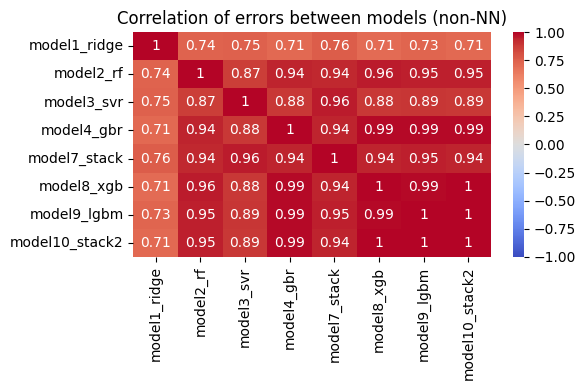

In [ ]:
#Error correlation between models using stored errors
error_dict = {}

if "result1" in globals():
    error_dict["model1_ridge"] = result1.errors
if "result2" in globals():
    error_dict["model2_rf"] = result2.errors
if "result3" in globals():
    error_dict["model3_svr"] = result3.errors
if "result4" in globals():
    error_dict["model4_gbr"] = result4.errors
if "result7" in globals():
    error_dict["model7_stack"] = result7.errors
if "result8" in globals():
    error_dict["model8_xgb"] = result8.errors
if "result9" in globals():
    error_dict["model9_lgbm"] = result9.errors
if "result10" in globals():
    error_dict["model10_stack2"] = result10.errors

if not error_dict:
    print("No non-NN result objects with errors found (result1, result2, ...). Run the model cells first.")
else:
    errors_df = pd.DataFrame(error_dict)

    print("First 5 rows of model errors (y_test - y_pred):")
    display(errors_df.head())

    corr_errors = errors_df.corr()
    print("\nCorrelation matrix of model errors:")
    display(corr_errors)

    plt.figure(figsize=(6, 4))
    sns.heatmap(corr_errors, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation of errors between models (non-NN)")
    plt.tight_layout()
    plt.show()

### Final stacking with ElasticNet meta-learner

We build a stacking model using the best GBR, Ridge, and SVR pipelines as base estimators and an ElasticNet regressor as the meta-learner, as even though most estimators make similar errors these estimators appeat to have a lower correlation. The meta-learner’s hyperparameters (alpha, l1_ratio) are tuned with Optuna. Final performance is evaluated on the held-out test set.

In [ ]:
# 0) Same split policy as run_experiment
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1) Define base estimators with names
# Using the FULL pipelines (NOT named_steps["reg"])
estimators = [
    ('gbstack', result10.best_estimator.named_steps["reg"]),
    ('ridge', result1.best_estimator.named_steps["reg"]),
    ('svr', result3.best_estimator.named_steps["reg"]),
]

# 2) Create StackingRegressor with ElasticNet as meta-learner
stacking_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=ElasticNet(random_state=42, max_iter=10_000),
    cv=3,  # 3-fold CV for generating meta-features
    n_jobs=-1
)


# Create param grid with 'final_estimator__' prefix
params_optuna = {
    "final_estimator__alpha": ("float", 1e-6, 1e1, True),
    "final_estimator__l1_ratio": ("float", 0.0, 1.0),
}

result_stack = run_experiment(
    stacking_reg,
    X_train, y_train,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance"],
    run_full_pipeline=True  # The stacking regressor handles everything
)

best_stacking = result_stack.best_estimator

# 4) Final evaluation on the held-out test split
pred_test = best_stacking.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
mse = mean_squared_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

print({"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2})

[I 2026-02-07 05:25:14,198] A new study created in memory with name: no-name-f261a9ef-1de9-433c-828c-d4e8d70f428f


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-02-07 05:31:25,834] Trial 0 finished with value: -0.09758694108915265 and parameters: {'final_estimator__alpha': 0.015780264351036268, 'final_estimator__l1_ratio': 0.7325193938543099}. Best is trial 0 with value: -0.09758694108915265.
[I 2026-02-07 05:37:41,942] Trial 1 finished with value: -0.18504216118552216 and parameters: {'final_estimator__alpha': 0.9283662669906473, 'final_estimator__l1_ratio': 0.5921867812717296}. Best is trial 0 with value: -0.09758694108915265.
[I 2026-02-07 05:43:52,598] Trial 2 finished with value: -0.07598218399065405 and parameters: {'final_estimator__alpha': 3.2544588221018124e-05, 'final_estimator__l1_ratio': 0.32631441841050657}. Best is trial 2 with value: -0.07598218399065405.
[I 2026-02-07 05:50:01,167] Trial 3 finished with value: -0.07597339999924652 and parameters: {'final_estimator__alpha': 6.748265423010555e-06, 'final_estimator__l1_ratio': 0.786325129702103}. Best is trial 3 with value: -0.07597339999924652.
[I 2026-02-07 05:56:07,094]

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2026-02-07 06:39:05,198] Trial 11 finished with value: -0.07597277054847616 and parameters: {'final_estimator__alpha': 1.679362773230056e-06, 'final_estimator__l1_ratio': 0.9731989725853286}. Best is trial 11 with value: -0.07597277054847616.
[I 2026-02-07 06:45:24,332] Trial 12 finished with value: -0.07597282355336495 and parameters: {'final_estimator__alpha': 1.3308809448097404e-06, 'final_estimator__l1_ratio': 0.9472611766352876}. Best is trial 11 with value: -0.07597277054847616.
[I 2026-02-07 06:51:31,894] Trial 13 finished with value: -0.07598233543362683 and parameters: {'final_estimator__alpha': 0.00017417968546059147, 'final_estimator__l1_ratio': 0.9592456982356332}. Best is trial 11 with value: -0.07597277054847616.
[I 2026-02-07 06:57:38,023] Trial 14 finished with value: -0.07597324507855806 and parameters: {'final_estimator__alpha': 8.51692362445019e-06, 'final_estimator__l1_ratio': 0.8784114853795449}. Best is trial 11 with value: -0.07597277054847616.
[I 2026-02-07 0

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 0.07458062960995027
RMSE: 0.09469461356466378
MSE: 0.008967069838161005
R^2: 0.8110744844880472


KeyboardInterrupt: 

**Comment:** The ElasticNet meta-learner blends L1 and L2 to combine GBR, Ridge, and SVR predictions. The printed test metrics show whether this final stacking improves over the best single model and over the other stacking; use the MAE summary table for a direct comparison.

### Model comparison (test metrics)

Summary of test-set metrics for each ML model below. Use this table to compare MAE, RMSE, MSE, and R² across models before moving on to the neural network.

In [ ]:
# Model name and each metric on the test set (MAE, RMSE, MSE, R2)
model_metrics = []
if "metrics1" in globals():
    model_metrics.append({"Model": "Ridge", **metrics1})
if "metrics2" in globals():
    model_metrics.append({"Model": "Random Forest", **metrics2})
if "metrics3" in globals():
    model_metrics.append({"Model": "SVR", **metrics3})
if "metrics4" in globals():
    model_metrics.append({"Model": "Gradient Boosting", **metrics4})
if "metrics7" in globals():
    model_metrics.append({"Model": "Stack (RF+SVR+GBR)", **metrics7})
if "metrics8" in globals():
    model_metrics.append({"Model": "XGBoost", **metrics8})
if "metrics9" in globals():
    model_metrics.append({"Model": "LightGBM", **metrics9})
if "metrics10" in globals():
    model_metrics.append({"Model": "Final stack (XGB+LGB+ElasticNet)", **metrics10})

if model_metrics:
    df_metrics = pd.DataFrame(model_metrics)
    # Reorder columns: Model first, then MAE, RMSE, MSE, R2
    df_metrics = df_metrics[["Model", "MAE", "RMSE", "MSE", "R2"]]
    df_metrics = df_metrics.rename(columns={"R2": "R²"}).round(6)
    display(df_metrics)
else:
    print("Run the model cells above to populate the metrics table.")

,Model,MAE,RMSE,MSE,R²
0,Ridge,0.104723,0.130512,0.017033,0.652259
1,Random Forest,0.076936,0.097646,0.009535,0.805346
2,SVR,0.078889,0.100380,0.010076,0.794294
3,Gradient Boosting,0.073014,0.092830,0.008617,0.824073
4,Stack (RF+SVR+GBR),0.076438,0.097012,0.009411,0.807865
5,XGBoost,0.072424,0.092270,0.008514,0.826190
6,LightGBM,0.072766,0.092400,0.008538,0.825700
7,Final stack (XGB+LGB+ElasticNet),0.072280,0.092073,0.008477,0.826930


### Cross-Validation MAE Scores

| Model | CV MAE |
|------|--------|
| Stacking (GBM + LightGBM) | **0.07556** |
| Gradient Boosting | 0.07597 |
| Stacking (XGB + LGBM + Ridge) | 0.07597 |
| XGBoost | 0.07846 |
| LightGBM | 0.07845 |
| Random Forest | 0.08075 |
| SVR (RBF) | 0.08212 |
| Ridge | 0.10437 |


Even thought the errors of the LightGBM and XGBoost are highly correlated their stacking regressor has the best CV score.

### 5.4 Neural Networks

We train several neural architectures on the scaled engineered features with Optuna tuning and early stopping:

- **MLP (`Choices13kNet`)** — feedforward network with weighted MAE loss.
- **ResNet (`Choices13kResNet`)** — residual MLP with Smooth L1 loss.
- **DCNv2** — cross-network + deep network for feature interactions.

Each block defines its own training helpers (`eval_epoch_*`, `train_nn_one_run_*`, `objective_*`) to avoid name clashes when running the notebook top to bottom.

**Data preparation.** We keep only numeric (and boolean) columns from the engineered features, split into 80% train / 20% test, scale with `StandardScaler`, and convert to PyTorch tensors and a DataLoader for training.

In [198]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [199]:
X = X.select_dtypes(include=[np.number, "bool"])

y = np.asarray(y, dtype=np.float32)

In [200]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train_df.shape, X_test_df.shape)


(11654, 36) (2914, 36)


In [201]:
# Build PyTorch tensors and sample weights for MLP (Choices13kNet)
scaler_mlp = StandardScaler()
X_tr_scaled = scaler_mlp.fit_transform(X_train_df.to_numpy(dtype=np.float32))
X_te_scaled = scaler_mlp.transform(X_test_df.to_numpy(dtype=np.float32))

input_dim = X_tr_scaled.shape[1]
X_tr_torch = torch.tensor(X_tr_scaled, dtype=torch.float32)
y_tr_torch = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
w_tr_torch = torch.ones_like(y_tr_torch)
X_te_torch = torch.tensor(X_te_scaled, dtype=torch.float32)
y_te_torch = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)
w_te_torch = torch.ones_like(y_te_torch)

**Model.** `Choices13kNet` is a feedforward network with configurable hidden layer sizes and dropout. The final layer outputs a single value in [0, 1] via Sigmoid for the choice rate.

In [202]:
class Choices13kNet(nn.Module):
    def __init__(self, input_dim, hidden=(128, 64, 32), dropout=0.0):
        super().__init__()
        layers = []
        dims = [input_dim] + list(hidden)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        layers.append(nn.Sigmoid())  # keep if y in [0,1]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [203]:
def weighted_smoothl1(pred, target, weight, beta=1.0):
    """
    pred/target/weight: (B,1)
    returns scalar
    """
    # per-sample loss
    loss = nn.functional.smooth_l1_loss(pred, target, beta=beta, reduction="none")  # (B,1)
    loss = loss * weight
    return loss.mean()

@torch.no_grad()
def mae_unweighted(pred, target):
    return torch.mean(torch.abs(pred - target)).item()

@torch.no_grad()
def mae_weighted(pred, target, weight):
    # weighted mean absolute error
    num = torch.sum(weight * torch.abs(pred - target))
    den = torch.sum(weight) + 1e-12
    return (num / den).item()


In [204]:
@torch.no_grad()
def eval_epoch_mlp(model, X, y, w):
    model.eval()
    Xd, yd, wd = X.to(device), y.to(device), w.to(device)
    pred = model(Xd)
    val_wmae = mae_weighted(pred, yd, wd)
    val_mae = mae_unweighted(pred, yd)
    return val_wmae, val_mae

def train_nn_one_run_mlp(
    model,
    train_loader,
    X_val, y_val, w_val,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=50,
    trial=None,
):
    best_metric = float("inf")   # we’ll early-stop on weighted MAE
    best_epoch = -1
    best_state = None
    patience_ctr = 0

    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0

        for xb, yb, wb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            wb = wb.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)

            loss = weighted_smoothl1(pred, yb, wb, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_wmae += mae_weighted(pred.detach(), yb, wb)

        train_wmae = running_wmae / len(train_loader)
        val_wmae, val_mae = eval_epoch_mlp(model, X_val, y_val, w_val)

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_metric - 1e-12
        if is_best:
            best_metric = val_wmae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(
                f"[{epoch:03d}] train wMAE={train_wmae:.5f} | "
                f"val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}{star}"
            )

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_metric, best_epoch, history


In [205]:
def objective_mlp(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)

    h1 = trial.suggest_categorical("h1", [32, 64, 128, 256])
    h2 = trial.suggest_categorical("h2", [32, 64, 128])
    h3 = trial.suggest_categorical("h3", [16, 32, 64])
    hidden = (h1, h2, h3)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_scores = []

    X_all = X_tr_torch
    y_all = y_tr_torch
    w_all = w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]

        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = Choices13kNet(input_dim, hidden, dropout).to(device)
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)

        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )

        val_wmae, _, _ = train_nn_one_run_mlp(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )

        fold_scores.append(val_wmae)

    return float(np.mean(fold_scores))


In [206]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(objective_mlp, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV wMAE:", study.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

[000] train wMAE=0.10127 | val wMAE=0.08687 | val MAE=0.08687 | lr=5.98e-03 ★
[050] train wMAE=0.07941 | val wMAE=0.08058 | val MAE=0.08058 | lr=5.98e-03
Early stopping at epoch 75 (best=35)
[000] train wMAE=0.16823 | val wMAE=0.13201 | val MAE=0.13201 | lr=3.59e-04 ★
[050] train wMAE=0.08448 | val wMAE=0.08317 | val MAE=0.08317 | lr=3.59e-04
Early stopping at epoch 88 (best=48)
[000] train wMAE=0.14567 | val wMAE=0.09989 | val MAE=0.09989 | lr=2.11e-03 ★
[050] train wMAE=0.08243 | val wMAE=0.08986 | val MAE=0.08986 | lr=5.27e-04
Early stopping at epoch 54 (best=14)
[000] train wMAE=0.15370 | val wMAE=0.11360 | val MAE=0.11360 | lr=4.71e-04 ★
[050] train wMAE=0.07193 | val wMAE=0.07693 | val MAE=0.07693 | lr=4.71e-04
Early stopping at epoch 96 (best=56)
[000] train wMAE=0.18265 | val wMAE=0.17770 | val MAE=0.17770 | lr=1.66e-04 ★
[050] train wMAE=0.08975 | val wMAE=0.08411 | val MAE=0.08411 | lr=1.66e-04 ★
[100] train wMAE=0.08649 | val wMAE=0.08141 | val MAE=0.08141 | lr=1.66e-04 ★
[1

In [207]:
bp = study.best_params
hidden_best = (bp["h1"], bp["h2"], bp["h3"])

# internal train/val split from TRAIN (for early stopping)
n_train = len(X_tr_torch)
perm = np.random.RandomState(SEED).permutation(n_train)
n_val = int(0.2 * n_train)
val_idx = perm[:n_val]
tr_idx = perm[n_val:]

X_tr = X_tr_torch[tr_idx]
y_tr = y_tr_torch[tr_idx]
w_tr = w_tr_torch[tr_idx]

X_val = X_tr_torch[val_idx]
y_val = y_tr_torch[val_idx]
w_val = w_tr_torch[val_idx]

model = Choices13kNet(input_dim, hidden_best, bp["dropout"]).to(device)
optimizer = optim.AdamW(model.parameters(), lr=bp["lr"], weight_decay=bp["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

train_loader = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp["batch_size"],
    shuffle=True,
)

best_val_wmae, best_epoch, history = train_nn_one_run_mlp(
    model=model,
    train_loader=train_loader,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer,
    scheduler=scheduler,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

# Evaluate on TEST
with torch.no_grad():
    pred_test = model(X_te_torch.to(device)).cpu()

test_mae = torch.mean(torch.abs(pred_test - y_te_torch)).item()
test_wmae = mae_weighted(pred_test, y_te_torch, w_te_torch)

print(f"Best epoch: {best_epoch}")
print(f"VAL wMAE: {best_val_wmae:.6f}")
print(f"TEST MAE: {test_mae:.6f} | TEST wMAE: {test_wmae:.6f}")


[000] train wMAE=0.12672 | val wMAE=0.09132 | val MAE=0.09132 | lr=8.06e-04 ★
[025] train wMAE=0.07221 | val wMAE=0.07689 | val MAE=0.07689 | lr=8.06e-04
[050] train wMAE=0.06742 | val wMAE=0.07671 | val MAE=0.07671 | lr=8.06e-04
[075] train wMAE=0.06290 | val wMAE=0.07720 | val MAE=0.07720 | lr=4.03e-04
Early stopping at epoch 88 (best=48)
Best epoch: 48
VAL wMAE: 0.076356
TEST MAE: 0.075094 | TEST wMAE: 0.075094


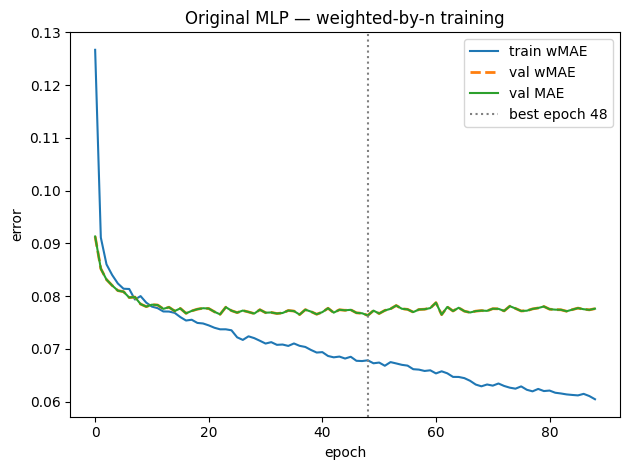

In [208]:
plt.figure()
plt.plot(history["train_wmae"], label="train wMAE", color="C0")
plt.plot(history["val_wmae"], label="val wMAE", color="C1", linestyle="--", linewidth=2)
plt.plot(history["val_mae"], label="val MAE", color="C2")
plt.axvline(best_epoch, linestyle=":", color="gray", label=f"best epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("error")
plt.legend()
plt.title("Original MLP — weighted-by-n training")
plt.tight_layout()
plt.show()


**MLP with normalization (Optuna).** Same architecture as `Choices13kNet` but with a normalization layer after each hidden activation; the norm type (`none`, `layer`, `batch`) is optimized by Optuna. Dropout remains a hyperparameter.

In [209]:
class Choices13kNetNorm(nn.Module):
    """Same as Choices13kNet but with optional normalization after each ReLU (optuna-optimized)."""
    def __init__(self, input_dim, hidden=(128, 64, 32), dropout=0.0, norm="none"):
        super().__init__()
        assert norm in ("none", "layer", "batch")
        layers = []
        dims = [input_dim] + list(hidden)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
            if norm == "layer":
                layers.append(nn.LayerNorm(dims[i + 1]))
            elif norm == "batch":
                layers.append(nn.BatchNorm1d(dims[i + 1]))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [210]:
@torch.no_grad()
def eval_epoch_mlp_norm(model, X, y, w):
    model.eval()
    Xd, yd, wd = X.to(device), y.to(device), w.to(device)
    pred = model(Xd)
    val_wmae = mae_weighted(pred, yd, wd)
    val_mae = mae_unweighted(pred, yd)
    return val_wmae, val_mae

def train_nn_one_run_mlp_norm(
    model,
    train_loader,
    X_val, y_val, w_val,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=50,
    trial=None,
):
    best_metric = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0
    history = {"train_wmae": [], "val_wmae": [], "val_mae": [], "lr": []}

    for epoch in range(max_epochs):
        model.train()
        running_wmae = 0.0
        for xb, yb, wb in train_loader:
            xb, yb, wb = xb.to(device), yb.to(device), wb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = weighted_smoothl1(pred, yb, wb, beta=1.0)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_wmae += mae_weighted(pred.detach(), yb, wb)

        train_wmae = running_wmae / len(train_loader)
        val_wmae, val_mae = eval_epoch_mlp_norm(model, X_val, y_val, w_val)

        if trial is not None:
            trial.report(val_wmae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if scheduler is not None:
            scheduler.step(val_wmae)

        history["train_wmae"].append(train_wmae)
        history["val_wmae"].append(val_wmae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_wmae < best_metric - 1e-12
        if is_best:
            best_metric, best_epoch = val_wmae, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] train wMAE={train_wmae:.5f} | val wMAE={val_wmae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")
        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_metric, best_epoch, history

In [211]:
def objective_mlp_norm(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    norm = trial.suggest_categorical("norm", ["none", "layer", "batch"])

    h1 = trial.suggest_categorical("h1", [32, 64, 128, 256])
    h2 = trial.suggest_categorical("h2", [32, 64, 128])
    h3 = trial.suggest_categorical("h3", [16, 32, 64])
    hidden = (h1, h2, h3)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    fold_scores = []
    X_all, y_all, w_all = X_tr_torch, y_tr_torch, w_tr_torch

    for fold, (tr_idx, va_idx) in enumerate(kf.split(np.arange(len(X_all)))):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        w_tr = w_all[tr_idx]
        X_va = X_all[va_idx]
        y_va = y_all[va_idx]
        w_va = w_all[va_idx]

        model = Choices13kNetNorm(input_dim, hidden, dropout, norm=norm).to(device)
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
        loader = DataLoader(
            TensorDataset(X_tr, y_tr, w_tr),
            batch_size=batch_size,
            shuffle=True,
        )
        val_wmae, _, _ = train_nn_one_run_mlp_norm(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            w_val=w_va,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )
        fold_scores.append(val_wmae)
    return float(np.mean(fold_scores))

In [212]:
study_norm = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study_norm.optimize(objective_mlp_norm, n_trials=25, show_progress_bar=True)
print("Best params:", study_norm.best_params)
print("Best CV wMAE:", study_norm.best_value)

  0%|          | 0/25 [00:00<?, ?it/s]

[000] train wMAE=0.12069 | val wMAE=0.09104 | val MAE=0.09104 | lr=2.65e-03 ★
[050] train wMAE=0.08352 | val wMAE=0.07973 | val MAE=0.07973 | lr=2.65e-03
[100] train wMAE=0.07956 | val wMAE=0.07743 | val MAE=0.07743 | lr=6.61e-04
Early stopping at epoch 137 (best=97)
[000] train wMAE=0.11494 | val wMAE=0.09376 | val MAE=0.09376 | lr=2.35e-03 ★
[050] train wMAE=0.06650 | val wMAE=0.07899 | val MAE=0.07899 | lr=2.35e-03
Early stopping at epoch 77 (best=37)
[000] train wMAE=0.11445 | val wMAE=0.09198 | val MAE=0.09198 | lr=3.33e-03 ★
[050] train wMAE=0.07515 | val wMAE=0.07865 | val MAE=0.07865 | lr=3.33e-03
[100] train wMAE=0.07104 | val wMAE=0.07755 | val MAE=0.07755 | lr=1.66e-03
Early stopping at epoch 141 (best=101)
[000] train wMAE=0.15447 | val wMAE=0.10384 | val MAE=0.10384 | lr=5.91e-04 ★
[050] train wMAE=0.07635 | val wMAE=0.07682 | val MAE=0.07682 | lr=5.91e-04
[100] train wMAE=0.07114 | val wMAE=0.07712 | val MAE=0.07712 | lr=1.48e-04
Early stopping at epoch 128 (best=88)
[000

In [213]:
bp_norm = study_norm.best_params
hidden_norm = (bp_norm["h1"], bp_norm["h2"], bp_norm["h3"])

model_norm = Choices13kNetNorm(
    input_dim, hidden_norm, bp_norm["dropout"], norm=bp_norm["norm"]
).to(device)
optimizer_norm = optim.AdamW(model_norm.parameters(), lr=bp_norm["lr"], weight_decay=bp_norm["weight_decay"])
scheduler_norm = optim.lr_scheduler.ReduceLROnPlateau(optimizer_norm, patience=15, factor=0.5)

train_loader_norm = DataLoader(
    TensorDataset(X_tr, y_tr, w_tr),
    batch_size=bp_norm["batch_size"],
    shuffle=True,
)

best_val_wmae_norm, best_epoch_norm, history_norm = train_nn_one_run_mlp_norm(
    model=model_norm,
    train_loader=train_loader_norm,
    X_val=X_val,
    y_val=y_val,
    w_val=w_val,
    optimizer=optimizer_norm,
    scheduler=scheduler_norm,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

with torch.no_grad():
    pred_test_norm = model_norm(X_te_torch.to(device)).cpu()
test_mae_norm = torch.mean(torch.abs(pred_test_norm - y_te_torch)).item()
test_wmae_norm = mae_weighted(pred_test_norm, y_te_torch, w_te_torch)
print(f"Best epoch: {best_epoch_norm} | VAL wMAE: {best_val_wmae_norm:.6f}")
print(f"TEST MAE: {test_mae_norm:.6f} | TEST wMAE: {test_wmae_norm:.6f}")

[000] train wMAE=0.11212 | val wMAE=0.08658 | val MAE=0.08658 | lr=9.77e-04 ★
[025] train wMAE=0.07574 | val wMAE=0.07667 | val MAE=0.07667 | lr=9.77e-04 ★
[050] train wMAE=0.06994 | val wMAE=0.07687 | val MAE=0.07687 | lr=9.77e-04
[075] train wMAE=0.06553 | val wMAE=0.07744 | val MAE=0.07744 | lr=4.89e-04
Early stopping at epoch 85 (best=45)
Best epoch: 45 | VAL wMAE: 0.075678
TEST MAE: 0.075344 | TEST wMAE: 0.075344


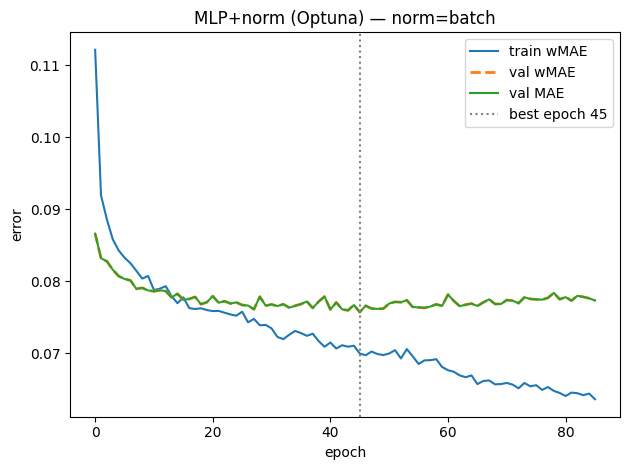

In [214]:
plt.figure()
plt.plot(history_norm["train_wmae"], label="train wMAE", color="C0")
plt.plot(history_norm["val_wmae"], label="val wMAE", color="C1", linestyle="--", linewidth=2)
plt.plot(history_norm["val_mae"], label="val MAE", color="C2")
plt.axvline(best_epoch_norm, linestyle=":", color="gray", label=f"best epoch {best_epoch_norm}")
plt.xlabel("epoch")
plt.ylabel("error")
plt.legend()
plt.title(f"MLP+norm (Optuna) — norm={bp_norm['norm']}")
plt.tight_layout()
plt.show()

In [215]:
class ResidualBlock(nn.Module):
    def __init__(self, d: int, hidden_mult: float = 2.0, dropout: float = 0.1):
        super().__init__()
        h = max(8, int(d * hidden_mult))
        self.norm = nn.LayerNorm(d)
        self.fc1 = nn.Linear(d, h)
        self.fc2 = nn.Linear(h, d)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.norm(x)
        z = self.fc1(z)
        z = self.act(z)
        z = self.drop(z)
        z = self.fc2(z)
        z = self.drop(z)
        return x + z


class Choices13kResNet(nn.Module):
    """
    Residual MLP for tabular regression to y in [0,1] (brate-like).
    If your target is NOT bounded, remove Sigmoid below.
    """
    def __init__(
        self,
        input_dim: int,
        d: int = 128,
        n_blocks: int = 3,
        hidden_mult: float = 2.0,
        dropout: float = 0.1,
        out_activation: str = "sigmoid",  # "sigmoid" or "none"
    ):
        super().__init__()
        self.inp = nn.Sequential(
            nn.Linear(input_dim, d),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.blocks = nn.Sequential(*[
            ResidualBlock(d, hidden_mult=hidden_mult, dropout=dropout)
            for _ in range(n_blocks)
        ])
        head = [nn.LayerNorm(d), nn.Linear(d, 1)]
        if out_activation == "sigmoid":
            head.append(nn.Sigmoid())
        self.head = nn.Sequential(*head)

    def forward(self, x):
        x = self.inp(x)
        x = self.blocks(x)
        return self.head(x)

In [216]:
def _mae_torch(pred, y):
    return torch.mean(torch.abs(pred - y)).item()

@torch.no_grad()
def eval_epoch_resnet(model, X, y, criterion):
    model.eval()
    X, y = X.to(device), y.to(device)
    pred = model(X)
    loss = criterion(pred, y).item()
    mae = _mae_torch(pred, y)
    return loss, mae


In [217]:
def train_nn_one_run_resnet(
    model,
    train_loader,
    X_val,
    y_val,
    criterion,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose=False,
    log_every=10,
    trial=None,
):
    history = {
        "train_mae": [],
        "val_mae": [],
        "lr": [],
    }

    best_val = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0

    for epoch in range(max_epochs):
        model.train()
        train_mae = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_mae += _mae_torch(pred.detach(), yb)

        train_mae /= len(train_loader)
        _, val_mae = eval_epoch_resnet(model, X_val, y_val, criterion)

        if trial is not None:
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_mae)

        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if val_mae < best_val - 1e-12:
            best_val = val_mae
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
            star = "★"
        else:
            patience_ctr += 1
            star = ""

        if verbose and epoch % log_every == 0:
            print(
                f"[{epoch:03d}] train MAE={train_mae:.5f} | "
                f"val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e} {star}"
            )

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    model.load_state_dict(best_state)
    return best_val, best_epoch, history


**Hyperparameter tuning.** Optuna minimizes mean validation MAE over 5-fold cross-validation, searching over learning rate, weight decay, batch size, dropout, and hidden layer sizes. The best trial’s parameters are used for the final refit.

In [218]:
X_np = X_train_df.to_numpy(dtype=np.float32)
y_np = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)
input_dim = X_np.shape[1]

def objective_resnet(trial):
    # ----- optimizer / training -----
    lr = trial.suggest_float("lr", 3e-4, 2e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 5e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])

    # ----- architecture -----
    d = trial.suggest_categorical("d", [64, 128, 256])
    n_blocks = trial.suggest_int("n_blocks", 2, 5)
    hidden_mult = trial.suggest_float("hidden_mult", 1.5, 3.5)
    dropout = trial.suggest_float("dropout", 0.0, 0.35)

    # (optional) could tune clip norm or patience, but keep stable
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    maes = []

    for fold, (tr, va) in enumerate(kf.split(X_np)):
        # ----- scale per fold -----
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_np[tr])
        X_va = scaler.transform(X_np[va])

        X_tr = torch.tensor(X_tr, dtype=torch.float32)
        y_tr = torch.tensor(y_np[tr], dtype=torch.float32)
        X_va = torch.tensor(X_va, dtype=torch.float32)
        y_va = torch.tensor(y_np[va], dtype=torch.float32)

        model = Choices13kResNet(
            input_dim=input_dim,
            d=d,
            n_blocks=n_blocks,
            hidden_mult=hidden_mult,
            dropout=dropout,
            out_activation="sigmoid",  # remove/none if target not in [0,1]
        ).to(device)

        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5)
        crit = nn.SmoothL1Loss()

        loader = DataLoader(
            TensorDataset(X_tr, y_tr),
            batch_size=batch_size,
            shuffle=True,
        )

        val_mae, _, _ = train_nn_one_run_resnet(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            criterion=crit,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),   # prune only on fold 0
            verbose=(fold == 0),                    # reduce log spam
            log_every=50,
        )

        maes.append(val_mae)

    return float(np.mean(maes))


**Refit and evaluate.** The best Optuna configuration is trained on the full training set. We plot train/validation MAE vs epoch, restore the best-epoch weights, compute test MAE, and save the model and metadata.

In [219]:

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(objective_resnet, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV MAE:", study.best_value)



  0%|          | 0/25 [00:00<?, ?it/s]

[000] train MAE=0.12782 | val MAE=0.09509 | lr=7.55e-03 ★
[050] train MAE=0.07746 | val MAE=0.08043 | lr=7.55e-03 
[100] train MAE=0.07205 | val MAE=0.07995 | lr=1.89e-03 
Early stopping at epoch 119 (best=79)
[000] train MAE=0.10459 | val MAE=0.08727 | lr=1.22e-02 ★
[050] train MAE=0.06642 | val MAE=0.07957 | lr=1.22e-02 
Early stopping at epoch 76 (best=36)
[000] train MAE=0.47267 | val MAE=0.47889 | lr=1.78e-02 ★
Early stopping at epoch 49 (best=9)
[000] train MAE=0.13077 | val MAE=0.09675 | lr=3.91e-04 ★
[050] train MAE=0.07856 | val MAE=0.07910 | lr=3.91e-04 ★
[100] train MAE=0.07480 | val MAE=0.07983 | lr=1.95e-04 
Early stopping at epoch 114 (best=74)
[000] train MAE=0.11477 | val MAE=0.09142 | lr=1.15e-03 ★
[050] train MAE=0.07671 | val MAE=0.08018 | lr=1.15e-03 
[100] train MAE=0.07287 | val MAE=0.07882 | lr=2.88e-04 
Early stopping at epoch 106 (best=66)
[000] train MAE=0.10735 | val MAE=0.09166 | lr=1.98e-03 ★
[050] train MAE=0.07044 | val MAE=0.08059 | lr=9.88e-04 
Early st

In [220]:
# internal train/val split (for early stopping / epoch selection)
idx = np.random.permutation(len(X_np))
n_val = int(0.2 * len(idx))
val_idx, tr_idx = idx[:n_val], idx[n_val:]

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_np[tr_idx])
X_val = scaler.transform(X_np[val_idx])

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_np[tr_idx], dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_np[val_idx], dtype=torch.float32)

bp = study.best_params

# ---- build residual model using the right params ----
model = Choices13kResNet(
    input_dim=input_dim,
    d=bp["d"],
    n_blocks=bp["n_blocks"],
    hidden_mult=bp["hidden_mult"],
    dropout=bp["dropout"],
    out_activation="sigmoid",  # set "none" if target not in [0,1]
).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=bp["lr"],
    weight_decay=bp["weight_decay"],
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
criterion = nn.SmoothL1Loss()

loader = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=bp["batch_size"],
    shuffle=True,
)

best_val_mae, best_epoch, history = train_nn_one_run_resnet(
    model=model,
    train_loader=loader,
    X_val=X_val,
    y_val=y_val,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=50,
)



[000] train MAE=0.10808 | val MAE=0.08895 | lr=6.30e-04 ★
[050] train MAE=0.07145 | val MAE=0.07824 | lr=6.30e-04 
[100] train MAE=0.06602 | val MAE=0.07823 | lr=1.57e-04 
Early stopping at epoch 107 (best=67)


In [221]:
X_test_np = scaler.transform(X_test_df.to_numpy(dtype=np.float32))
X_test_t = torch.tensor(X_test_np, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32).to(device)

with torch.no_grad():
    test_pred = model(X_test_t)

test_mae = mean_absolute_error(
    y_test_t.cpu().numpy().ravel(),
    test_pred.cpu().numpy().ravel(),
)

print(f"BEST VAL MAE: {best_val_mae:.6f}")
print(f"TEST MAE    : {test_mae:.6f}")


BEST VAL MAE: 0.076715
TEST MAE    : 0.075757


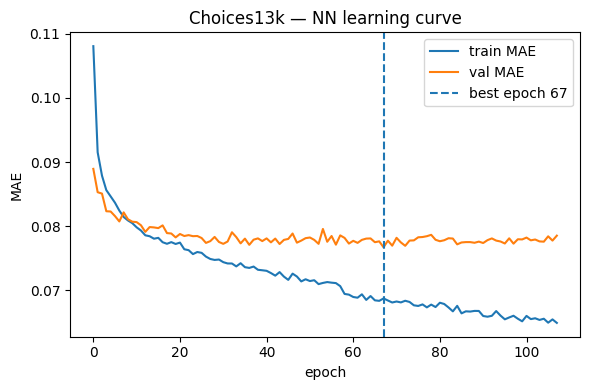

In [222]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_mae"], label="train MAE")
plt.plot(history["val_mae"], label="val MAE")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Choices13k — NN learning curve")
plt.tight_layout()
plt.show()


In [223]:
torch.save(
    {
        "state_dict": model.state_dict(),
        "best_params": bp,
        "best_epoch": best_epoch,
        "best_val_mae": best_val_mae,
        "scaler": scaler,
        "history": history,
    },
    "best_choices13k_nn.pt",
)

print("Saved best_choices13k_nn.pt")


Saved best_choices13k_nn.pt


In [224]:
# =========================
# Cell 3 — DCNv2 model
# =========================
class CrossLayer(nn.Module):
    """
    x_{l+1} = x_l + x0 * (W x_l) + b
    Shapes: x0, x_l: (B, d); W: (d, d); b: (d,)
    """
    def __init__(self, d: int, dropout: float = 0.0):
        super().__init__()
        self.W = nn.Linear(d, d, bias=True)  # includes b
        self.drop = nn.Dropout(dropout)

    def forward(self, x0, x):
        xw = self.W(x)          # (B, d)
        out = x + x0 * xw       # elementwise product -> explicit crosses
        return self.drop(out)


class DCNv2(nn.Module):
    """
    DCN v2-ish: CrossNet + DeepNet, then concat -> head.
    Numeric-only version (your pipeline is numeric/bool after select_dtypes).
    """
    def __init__(
        self,
        input_dim: int,
        n_cross: int = 3,
        deep_dims=(256, 128),
        dropout: float = 0.1,
        out_activation: str = "sigmoid",  # "sigmoid" if y in [0,1], else "none"
    ):
        super().__init__()
        self.input_dim = input_dim

        # Cross network
        self.cross_layers = nn.ModuleList([CrossLayer(input_dim, dropout=dropout) for _ in range(n_cross)])

        # Deep network
        deep = []
        prev = input_dim
        for h in deep_dims:
            deep += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        self.deep = nn.Sequential(*deep) if len(deep) else nn.Identity()
        deep_out_dim = prev if len(deep) else input_dim

        # Head over concat([cross_out, deep_out])
        self.head = nn.Linear(input_dim + deep_out_dim, 1)

        if out_activation == "sigmoid":
            self.out_act = nn.Sigmoid()
        else:
            self.out_act = nn.Identity()

    def forward(self, x):
        # x: (B, d)
        x0 = x
        xc = x
        for layer in self.cross_layers:
            xc = layer(x0, xc)          # (B, d)

        xd = self.deep(x)               # (B, deep_out_dim)
        z = torch.cat([xc, xd], dim=1)  # (B, d + deep_out_dim)
        y = self.head(z)                # (B, 1)
        return self.out_act(y)


In [225]:
# ==========================================
# Cell 4 — training utilities (MAE + loop)
# ==========================================
def _mae_torch_dcn(pred: torch.Tensor, y: torch.Tensor) -> float:
    return torch.mean(torch.abs(pred - y)).item()

@torch.no_grad()
def eval_epoch_dcn(model, X, y, criterion):
    model.eval()
    Xd, yd = X.to(device), y.to(device)
    pred = model(Xd)
    loss = criterion(pred, yd).item()
    mae = _mae_torch_dcn(pred, yd)
    return loss, mae

def train_nn_one_run_dcn(
    model,
    train_loader,
    X_val,
    y_val,
    criterion,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose: bool = False,
    log_every: int = 50,
    trial=None,
):
    history = {"train_mae": [], "val_mae": [], "lr": []}
    best_val = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0

    for epoch in range(max_epochs):
        model.train()
        running_mae = 0.0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_mae += _mae_torch_dcn(pred.detach(), yb)

        train_mae = running_mae / len(train_loader)
        _, val_mae = eval_epoch_dcn(model, X_val, y_val, criterion)

        if trial is not None:
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if scheduler is not None:
            scheduler.step(val_mae)

        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = val_mae < best_val - 1e-12
        if is_best:
            best_val = val_mae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] train MAE={train_mae:.5f} | val MAE={val_mae:.5f} | lr={optimizer.param_groups[0]['lr']:.2e}{star}")

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val, best_epoch, history


In [226]:
# =====================================================
# Cell 5 — Optuna objective (KFold on train, per-fold scaling)
# =====================================================
X_np = X_train_df.to_numpy(dtype=np.float32)
y_np = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)
input_dim = X_np.shape[1]

def objective_dcn(trial):
    # training hparams
    lr = trial.suggest_float("lr", 3e-4, 2e-2, log=True)
    wd = trial.suggest_float("weight_decay", 1e-8, 5e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.35)

    # DCN structure
    n_cross = trial.suggest_int("n_cross", 1, 5)
    d1 = trial.suggest_categorical("d1", [64, 128, 256, 512])
    d2 = trial.suggest_categorical("d2", [0, 64, 128, 256])  # 0 => no 2nd layer
    deep_dims = (d1,) if d2 == 0 else (d1, d2)

    kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
    maes = []

    for fold, (tr, va) in enumerate(kf.split(X_np)):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_np[tr])
        X_va = scaler.transform(X_np[va])

        X_tr = torch.tensor(X_tr, dtype=torch.float32)
        y_tr = torch.tensor(y_np[tr], dtype=torch.float32)
        X_va = torch.tensor(X_va, dtype=torch.float32)
        y_va = torch.tensor(y_np[va], dtype=torch.float32)

        model = DCNv2(
            input_dim=input_dim,
            n_cross=n_cross,
            deep_dims=deep_dims,
            dropout=dropout,
            out_activation="sigmoid",  # set "none" if y not in [0,1]
        ).to(device)

        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=15, factor=0.5)
        crit = nn.SmoothL1Loss()

        loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

        val_mae, _, _ = train_nn_one_run_dcn(
            model=model,
            train_loader=loader,
            X_val=X_va,
            y_val=y_va,
            criterion=crit,
            optimizer=opt,
            scheduler=sch,
            max_epochs=300,
            patience=40,
            trial=(trial if fold == 0 else None),
            verbose=(fold == 0),
            log_every=50,
        )

        maes.append(val_mae)

    return float(np.mean(maes))


In [227]:
# =========================
# Cell 6 — run Optuna
# =========================
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective_dcn, n_trials=25, show_progress_bar=True)

print("Best params:", study.best_params)
print("Best CV MAE:", study.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

[000] train MAE=0.09994 | val MAE=0.08382 | lr=9.06e-03 ★
[050] train MAE=0.05150 | val MAE=0.08188 | lr=2.26e-03
Early stopping at epoch 53 (best=13)
[000] train MAE=0.10751 | val MAE=0.08784 | lr=5.27e-04 ★
[050] train MAE=0.05544 | val MAE=0.07862 | lr=1.32e-04
Early stopping at epoch 54 (best=14)
[000] train MAE=0.10738 | val MAE=0.08493 | lr=2.22e-03 ★
[050] train MAE=0.06257 | val MAE=0.07847 | lr=1.11e-03
Early stopping at epoch 59 (best=19)
[000] train MAE=0.13117 | val MAE=0.09077 | lr=1.32e-03 ★
[050] train MAE=0.06622 | val MAE=0.07778 | lr=6.60e-04
Early stopping at epoch 67 (best=27)
[000] train MAE=0.21007 | val MAE=0.13474 | lr=3.67e-04 ★
[050] train MAE=0.07323 | val MAE=0.07766 | lr=3.67e-04
[100] train MAE=0.06941 | val MAE=0.07678 | lr=1.84e-04
Early stopping at epoch 122 (best=82)
[000] train MAE=0.10364 | val MAE=0.08351 | lr=1.85e-03 ★
[050] train MAE=0.06298 | val MAE=0.07864 | lr=9.23e-04
Early stopping at epoch 60 (best=20)
[000] train MAE=0.11010 | val MAE=0.0

In [228]:
# ==========================================================
# Cell 7 — refit best DCNv2 with internal train/val for epochs
# ==========================================================
# internal train/val split from TRAIN (not test)
idx = np.random.permutation(len(X_np))
n_val = int(0.2 * len(idx))
val_idx, tr_idx = idx[:n_val], idx[n_val:]

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_np[tr_idx])
X_val = scaler.transform(X_np[val_idx])

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_np[tr_idx], dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_np[val_idx], dtype=torch.float32)

bp = study.best_params
deep_dims = (bp["d1"],) if bp["d2"] == 0 else (bp["d1"], bp["d2"])

model = DCNv2(
    input_dim=input_dim,
    n_cross=bp["n_cross"],
    deep_dims=deep_dims,
    dropout=bp["dropout"],
    out_activation="sigmoid",
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=bp["lr"], weight_decay=bp["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
criterion = nn.SmoothL1Loss()

loader = DataLoader(
    TensorDataset(X_tr, y_tr),
    batch_size=bp["batch_size"],
    shuffle=True,
)

best_val_mae, best_epoch, history = train_nn_one_run_dcn(
    model=model,
    train_loader=loader,
    X_val=X_val,
    y_val=y_val,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

print(f"Refit: best_epoch={best_epoch} | best_val_mae={best_val_mae:.6f}")


[000] train MAE=0.19855 | val MAE=0.12942 | lr=3.67e-04 ★
[025] train MAE=0.07743 | val MAE=0.07837 | lr=3.67e-04 ★
[050] train MAE=0.07323 | val MAE=0.07729 | lr=3.67e-04
[075] train MAE=0.07086 | val MAE=0.07678 | lr=3.67e-04
[100] train MAE=0.06928 | val MAE=0.07685 | lr=3.67e-04
[125] train MAE=0.06739 | val MAE=0.07664 | lr=1.84e-04
[150] train MAE=0.06633 | val MAE=0.07684 | lr=4.59e-05
Early stopping at epoch 157 (best=117)
Refit: best_epoch=117 | best_val_mae=0.076412


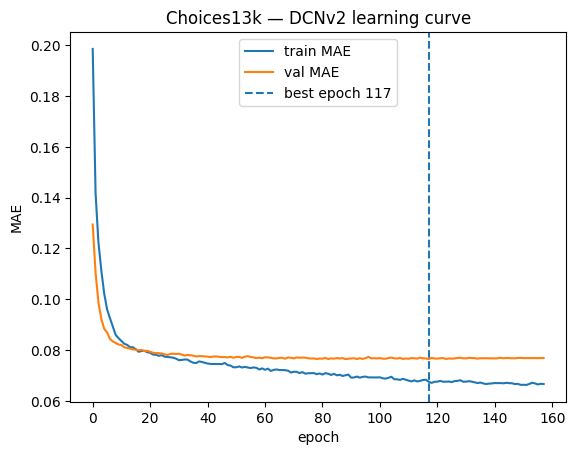

In [229]:
# ==========================================
# Cell 8 — plot learning curve
# ==========================================
plt.figure()
plt.plot(history["train_mae"], label="train MAE")
plt.plot(history["val_mae"], label="val MAE")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Choices13k — DCNv2 learning curve")
plt.show()


In [230]:
# ==========================================
# Cell 9 — evaluate on TEST (untouched)
# ==========================================
X_test_np = scaler.transform(X_test_df.to_numpy(dtype=np.float32))
X_test_t = torch.tensor(X_test_np, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

with torch.no_grad():
    test_pred = model(X_test_t).detach().cpu().numpy().reshape(-1)

test_mae = mean_absolute_error(y_test_t.cpu().numpy().reshape(-1), test_pred)
print(f"TEST MAE: {test_mae:.6f}")


TEST MAE: 0.074231


## Lottery-based neural network (LotteryEncoder + ChoicesRegressor)

We train a second neural network that operates directly on the raw lottery structure: each option is a list of (probability, outcome) pairs. The model encodes lottery A and lottery B with a shared encoder (token MLP + attention and mean/max pooling), then compares the two embeddings to predict the choice rate for B. This uses the same train/validation/test split as the rest of the notebook.

**Lottery data.** We parse lotteries A and B and the target from `df_full`, pad to a common length with masks, and apply the same 80/20 train–test then 80/20 train–val split. Engineered features X are aligned to these splits for the hybrid model.

In [231]:
def parse_lottery(cell):
    """cell is already a list like [[p,x], ...]"""
    L = cell
    return [[float(px[0]), float(px[1])] for px in L]

A_list = [parse_lottery(v) for v in df_full["A"].tolist()]
B_list = [parse_lottery(v) for v in df_full["B"].tolist()]
y_all = df_full["brate"].to_numpy(dtype=np.float32)  # (N,)

max_na = max(len(a) for a in A_list)
max_nb = max(len(b) for b in B_list)

def to_tensor(lottery_list, max_len):
    """Pad to (N, max_len, 2) and mask (N, max_len)"""
    N = len(lottery_list)
    L = np.zeros((N, max_len, 2), dtype=np.float32)
    mask = np.zeros((N, max_len), dtype=bool)
    for i, lot in enumerate(lottery_list):
        n = len(lot)
        L[i, :n] = np.asarray(lot, dtype=np.float32)
        mask[i, :n] = True
    return torch.from_numpy(L), torch.from_numpy(mask)

A_tensor, maskA = to_tensor(A_list, max_na)
B_tensor, maskB = to_tensor(B_list, max_nb)
y_tensor = torch.from_numpy(y_all).float()  # (N,)

print("A:", A_tensor.shape, "maskA:", maskA.shape)
print("B:", B_tensor.shape, "maskB:", maskB.shape)
print("y:", y_tensor.shape)


A: torch.Size([14568, 2, 2]) maskA: torch.Size([14568, 2])
B: torch.Size([14568, 9, 2]) maskB: torch.Size([14568, 9])
y: torch.Size([14568])


**Lottery model.** `LotteryEncoder` maps each lottery (list of (p, x) outcomes) to a fixed-size vector via token-level features, an MLP, and attention plus mean/max pooling. `ChoicesRegressor` concatenates the encodings of A and B with the engineered feature matrix X and predicts brate with a small head.

In [232]:
# Engineered features aligned with df_full row order
X_all = np.asarray(X.values, dtype=np.float32)  # (N, D)
print("X_all:", X_all.shape)


X_all: (14568, 36)


In [233]:
# Engineered features aligned with df_full row order
X_all = np.asarray(X.values, dtype=np.float32)  # (N, D)
print("X_all:", X_all.shape)


X_all: (14568, 36)


**Dataset and training helper.** We define `LotteryDataset` and `collate_lottery`, set the device and `input_dim_engineered`, and a helper `train_lottery_one_run` that trains for up to `max_epochs` with early stopping on validation MAE and returns the best validation MAE and best state dict. This is used by Optuna and by the final refit.

In [234]:
# Train/val/test split for lottery model (80% train, 20% test; then 80/20 train/val)
idx = np.arange(len(y_all))
np.random.seed(42)
np.random.shuffle(idx)
n_test = int(0.2 * len(idx))
test_idx = idx[:n_test]
train_val_idx = idx[n_test:]
n_val = int(0.2 * len(train_val_idx))
val_idx = train_val_idx[:n_val]
tr_idx = train_val_idx[n_val:]

In [235]:
# lottery tensors
A_tr, A_val, A_test = A_tensor[tr_idx], A_tensor[val_idx], A_tensor[test_idx]
B_tr, B_val, B_test = B_tensor[tr_idx], B_tensor[val_idx], B_tensor[test_idx]
mA_tr, mA_val, mA_test = maskA[tr_idx], maskA[val_idx], maskA[test_idx]
mB_tr, mB_val, mB_test = maskB[tr_idx], maskB[val_idx], maskB[test_idx]
y_tr, y_val, y_test = y_tensor[tr_idx], y_tensor[val_idx], y_tensor[test_idx]  # (n,)

# scale engineered features: fit on train only
scaler_X = StandardScaler()
X_tr_np = scaler_X.fit_transform(X_all[tr_idx])
X_val_np = scaler_X.transform(X_all[val_idx])
X_test_np = scaler_X.transform(X_all[test_idx])

X_tr = torch.from_numpy(X_tr_np).float()
X_val = torch.from_numpy(X_val_np).float()
X_test = torch.from_numpy(X_test_np).float()

input_dim_engineered = X_tr.shape[1]
print("Engineered dims:", input_dim_engineered)


Engineered dims: 36


In [236]:
class LotteryEncoder(nn.Module):
    """
    L: (B,N,2) with [p,x]
    mask: (B,N) bool
    returns: (B,d_model)
    """
    def __init__(self, d_model=64, d_hidden=128, dropout=0.1):
        super().__init__()
        self.token_mlp = nn.Sequential(
            nn.Linear(8, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_model),
            nn.ReLU(),
        )
        self.attn = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.Tanh(),
            nn.Linear(d_hidden, 1),
        )
        self.out = nn.Sequential(
            nn.Linear(3 * d_model, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_model),
        )

    def forward(self, L, mask=None):
        p = L[..., 0].clamp_min(1e-12)
        x = L[..., 1]

        if mask is not None:
            p = p * mask.to(L.dtype)
            p = p / p.sum(dim=1, keepdim=True).clamp_min(1e-12)
        else:
            p = p / p.sum(dim=1, keepdim=True).clamp_min(1e-12)

        logp = torch.log(p.clamp_min(1e-12))

        feats = torch.stack(
            [x, x.abs(), x * x, torch.sign(x), p, logp, p * x, p * x.abs()],
            dim=-1,
        )  # (B,N,8)

        h = self.token_mlp(feats)  # (B,N,d)

        scores = self.attn(h).squeeze(-1)  # (B,N)
        if mask is not None:
            scores = scores.masked_fill(~mask, float("-inf"))
        w = F.softmax(scores, dim=1).unsqueeze(-1)  # (B,N,1)
        h_attn = (w * h).sum(dim=1)  # (B,d)

        if mask is not None:
            denom = mask.sum(dim=1, keepdim=True).clamp_min(1).to(L.dtype)
            h_mean = (h * mask.unsqueeze(-1).to(L.dtype)).sum(dim=1) / denom
            h_max = h.masked_fill(~mask.unsqueeze(-1), float("-inf")).max(dim=1).values
            h_max = torch.where(torch.isfinite(h_max), h_max, torch.zeros_like(h_max))
        else:
            h_mean = h.mean(dim=1)
            h_max = h.max(dim=1).values

        z = torch.cat([h_attn, h_mean, h_max], dim=-1)  # (B,3d)
        return self.out(z)  # (B,d)


class ChoicesRegressor(nn.Module):
    def __init__(self, d_model_enc=64, d_hidden_enc=128, d_hidden_head=128, dropout=0.1, input_dim_engineered=0):
        super().__init__()
        self.enc = LotteryEncoder(d_model=d_model_enc, d_hidden=d_hidden_enc, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(4 * d_model_enc + input_dim_engineered, d_hidden_head),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden_head, 1),
            nn.Sigmoid(),  # brate in [0,1]
        )

    def forward(self, A, B, maskA=None, maskB=None, X_engineered=None):
        zA = self.enc(A, maskA)
        zB = self.enc(B, maskB)
        lottery_feats = torch.cat([zA, zB, zA - zB, zA * zB], dim=-1)  # (B,4d)
        if X_engineered is not None:
            feats = torch.cat([lottery_feats, X_engineered], dim=-1)
        else:
            feats = lottery_feats
        return self.head(feats).squeeze(-1)  # (B,)


In [237]:
class LotteryDataset(Dataset):
    def __init__(self, A, B, maskA, maskB, y, X_engineered):
        self.A, self.B = A, B
        self.maskA, self.maskB = maskA, maskB
        self.y = y
        self.X = X_engineered

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.A[i], self.B[i], self.maskA[i], self.maskB[i], self.y[i], self.X[i]

def collate_lottery(batch):
    A = torch.stack([b[0] for b in batch])
    B = torch.stack([b[1] for b in batch])
    mA = torch.stack([b[2] for b in batch])
    mB = torch.stack([b[3] for b in batch])
    y  = torch.stack([b[4] for b in batch])
    X  = torch.stack([b[5] for b in batch])
    return A, B, mA, mB, y, X


**Refit best lottery model and evaluate.** We train the best Optuna configuration on the full lottery train split, restore the best-epoch weights, and report test MAE.

In [238]:
def train_lottery_one_run(
    model,
    train_loader,
    A_val, B_val, mA_val, mB_val, X_val, y_val,
    *,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=200,
    patience=30,
    verbose=False,
    log_every=25,
    trial=None,
):
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
    criterion = nn.SmoothL1Loss()

    best_val = float("inf")
    best_state = None
    best_epoch = -1
    patience_ctr = 0

    A_val = A_val.to(device); B_val = B_val.to(device)
    mA_val = mA_val.to(device); mB_val = mB_val.to(device)
    X_val = X_val.to(device); y_val = y_val.to(device)

    for epoch in range(max_epochs):
        model.train()
        for A, B, mA, mB, y, X_eng in train_loader:
            A = A.to(device); B = B.to(device)
            mA = mA.to(device); mB = mB.to(device)
            y = y.to(device)
            X_eng = X_eng.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(A, B, mA, mB, X_engineered=X_eng)  # (B,)
            loss = criterion(pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_val = model(A_val, B_val, mA_val, mB_val, X_engineered=X_val)
            val_mae = torch.mean(torch.abs(pred_val - y_val)).item()

        if trial is not None:
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        scheduler.step(val_mae)

        is_best = val_mae < best_val - 1e-12
        if is_best:
            best_val = val_mae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1

        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            star = " ★" if is_best else ""
            print(f"[{epoch:03d}] val MAE={val_mae:.5f} lr={optimizer.param_groups[0]['lr']:.2e}{star}")

        if patience_ctr >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val, best_epoch, best_state


In [239]:
train_ds = LotteryDataset(A_tr, B_tr, mA_tr, mB_tr, y_tr, X_tr)
val_pack = (A_val, B_val, mA_val, mB_val, X_val, y_val)

def objective_lottery(trial):
    lr = trial.suggest_float("lr", 1e-4, 2e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    d_model_enc = trial.suggest_categorical("d_model_enc", [32, 64, 128])
    d_hidden_enc = trial.suggest_categorical("d_hidden_enc", [64, 128, 256])
    d_hidden_head = trial.suggest_categorical("d_hidden_head", [64, 128, 256])

    model = ChoicesRegressor(
        d_model_enc=d_model_enc,
        d_hidden_enc=d_hidden_enc,
        d_hidden_head=d_hidden_head,
        dropout=dropout,
        input_dim_engineered=input_dim_engineered,
    )

    loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=collate_lottery,
    )

    best_val_mae, _, _ = train_lottery_one_run(
        model,
        loader,
        *val_pack,
        lr=lr,
        weight_decay=weight_decay,
        max_epochs=200,
        patience=30,
        verbose=False,
        trial=trial,
    )
    return best_val_mae

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_lot = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study_lot.optimize(objective_lottery, n_trials=15, show_progress_bar=True)

print("Best params:", study_lot.best_params)
print("Best val MAE:", study_lot.best_value)


  0%|          | 0/15 [00:00<?, ?it/s]

Best params: {'lr': 0.00023182341340528985, 'weight_decay': 7.903942202074564e-08, 'batch_size': 128, 'dropout': 0.12830107342517946, 'd_model_enc': 32, 'd_hidden_enc': 256, 'd_hidden_head': 128}
Best val MAE: 0.07521038502454758


In [240]:
bp = study_lot.best_params

model_lot = ChoicesRegressor(
    d_model_enc=bp["d_model_enc"],
    d_hidden_enc=bp["d_hidden_enc"],
    d_hidden_head=bp["d_hidden_head"],
    dropout=bp["dropout"],
    input_dim_engineered=input_dim_engineered,
)

train_loader = DataLoader(
    train_ds,
    batch_size=bp["batch_size"],
    shuffle=True,
    collate_fn=collate_lottery,
)

best_val_mae, best_epoch, best_state = train_lottery_one_run(
    model_lot,
    train_loader,
    *val_pack,
    lr=bp["lr"],
    weight_decay=bp["weight_decay"],
    max_epochs=500,
    patience=40,
    verbose=True,
    log_every=25,
)

if best_state is not None:
    model_lot.load_state_dict(best_state)

model_lot.eval()
with torch.no_grad():
    pred_test = model_lot(
        A_test.to(device),
        B_test.to(device),
        mA_test.to(device),
        mB_test.to(device),
        X_engineered=X_test.to(device),
    )
    test_mae = torch.mean(torch.abs(pred_test - y_test.to(device))).item()

print(f"Best epoch: {best_epoch} | Best val MAE: {best_val_mae:.6f} | TEST MAE: {test_mae:.6f}")


[000] val MAE=0.21445 lr=2.32e-04 ★
[025] val MAE=0.08010 lr=2.32e-04
[050] val MAE=0.07734 lr=2.32e-04
[075] val MAE=0.07651 lr=2.32e-04
[100] val MAE=0.07569 lr=2.32e-04
[125] val MAE=0.07597 lr=1.16e-04
Early stopping at epoch 142 (best=102)
Best epoch: 102 | Best val MAE: 0.075553 | TEST MAE: 0.076135
